In [ ]:
%pip install ucimlrepo

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from IPython.display import display
from typing import Any, Dict

"""
Load the Cardiotocography dataset from UCI repository.
Reference:
    https://archive.ics.uci.edu/dataset/193/cardiotocography
"""

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

CTG_TARGET_COLS = ["NSP", "CLASS"]
NSP_LABELS = {1: "Normal", 2: "Suspect", 3: "Pathologic"}

# 1.Data Loading
def load_cardiotocography_dataset() -> pd.DataFrame:

    ctg = fetch_ucirepo(id=193)

    if ctg.data is None:
        raise ValueError("Failed to fetch dataset from UCI repository.")

    # Combine features and targets
    df = pd.concat([ctg.data.features, ctg.data.targets], axis=1)

    return df

# 1.1 Exploring dataset
def explore_dataset(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Returns:
        dict: Summary statistics including column types, shape, etc.
    """
    # Identify column types
    cat_cols = [col for col in df.columns if df[col].dtype == 'object']
    num_cols = [col for col in df.columns if df[col].dtype != 'object']

    summary = {
        'shape': df.shape,
        'categorical_columns': cat_cols,
        'numerical_columns': num_cols,
        'total_samples': df.shape[0],
        'total_features': df.shape[1]
    }

    # Display overview
    print("1. DATASET OVERVIEW")
    display(df.head(10))
    print(f"\nColumn Data Types:")
    print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
    print(f"Numerical columns ({len(num_cols)}): {num_cols}")
    print(f"\nDataset Summary:")
    print(f"Total samples: {summary['total_samples']:,}")
    print(f"Total features: {summary['total_features']}")

    return summary
# Load and explore data
df = load_cardiotocography_dataset()
dataset_summary = explore_dataset(df)

1. DATASET OVERVIEW


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,CLASS,NSP
0,120,0.000,0.0,0.000,0.000,0.0,0.000,73,0.5,43,2.4,64,62,126,2,0,120,137,121,73,1,9,2
1,132,0.006,0.0,0.006,0.003,0.0,0.000,17,2.1,0,10.4,130,68,198,6,1,141,136,140,12,0,6,1
2,133,0.003,0.0,0.008,0.003,0.0,0.000,16,2.1,0,13.4,130,68,198,5,1,141,135,138,13,0,6,1
3,134,0.003,0.0,0.008,0.003,0.0,0.000,16,2.4,0,23.0,117,53,170,11,0,137,134,137,13,1,6,1
4,132,0.007,0.0,0.008,0.000,0.0,0.000,16,2.4,0,19.9,117,53,170,9,0,137,136,138,11,1,2,1
5,134,0.001,0.0,0.010,0.009,0.0,0.002,26,5.9,0,0.0,150,50,200,5,3,76,107,107,170,0,8,3
6,134,0.001,0.0,0.013,0.008,0.0,0.003,29,6.3,0,0.0,150,50,200,6,3,71,107,106,215,0,8,3
7,122,0.000,0.0,0.000,0.000,0.0,0.000,83,0.5,6,15.6,68,62,130,0,0,122,122,123,3,1,9,3
8,122,0.000,0.0,0.002,0.000,0.0,0.000,84,0.5,5,13.6,68,62,130,0,0,122,122,123,3,1,9,3
9,122,0.000,0.0,0.003,0.000,0.0,0.000,86,0.3,6,10.6,68,62,130,1,0,122,122,123,1,1,9,3



Column Data Types:
Categorical columns (0): []
Numerical columns (23): ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'CLASS', 'NSP']

Dataset Summary:
Total samples: 2,126
Total features: 23


In [ ]:
#get a concise summary of the dataset including data types, non-null counts, and memory usage.
df.info()
#.describe method enable us to detect outliers in the data for further investigation
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   int64  
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   int64  
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   int64  
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   int64  
 12  Min       2126 non-null   int64  
 13  Max       2126 non-null   int64  
 14  Nmax      2126 non-null   int64  
 15  Nzeros    2126 non-null   int64  
 16  Mode      2126 non-null   int64  
 17  Mean      2126 non-null   int64  
 18  Median    2126 non-null   int64  
 19  Variance  2126 non-null   int64  
 20  Tendency  2126 non-null   int6

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,CLASS,NSP
count,2126.00,2126.00,2126.00,2126.00,2126.00,2126.0,2126.0,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00
mean,133.30,0.00,0.01,0.00,0.00,0.0,0.0,46.99,1.33,9.85,8.19,70.45,93.58,164.03,4.07,0.32,137.45,134.61,138.09,18.81,0.32,4.51,1.30
std,9.84,0.00,0.05,0.00,0.00,0.0,0.0,17.19,0.88,18.40,5.63,38.96,29.56,17.94,2.95,0.71,16.38,15.59,14.47,28.98,0.61,3.03,0.61
min,106.00,0.00,0.00,0.00,0.00,0.0,0.0,12.00,0.20,0.00,0.00,3.00,50.00,122.00,0.00,0.00,60.00,73.00,77.00,0.00,-1.00,1.00,1.00
25%,126.00,0.00,0.00,0.00,0.00,0.0,0.0,32.00,0.70,0.00,4.60,37.00,67.00,152.00,2.00,0.00,129.00,125.00,129.00,2.00,0.00,2.00,1.00
50%,133.00,0.00,0.00,0.00,0.00,0.0,0.0,49.00,1.20,0.00,7.40,67.50,93.00,162.00,3.00,0.00,139.00,136.00,139.00,7.00,0.00,4.00,1.00
75%,140.00,0.01,0.00,0.01,0.00,0.0,0.0,61.00,1.70,11.00,10.80,100.00,120.00,174.00,6.00,0.00,148.00,145.00,148.00,24.00,1.00,7.00,1.00
max,160.00,0.02,0.48,0.02,0.02,0.0,0.0,87.00,7.00,91.00,50.70,180.00,159.00,238.00,18.00,10.00,187.00,182.00,186.00,269.00,1.00,10.00,3.00


In [ ]:
# 2. Cleaning missing values on dataset
"""
Clean missing values in the dataset by replacing specified placeholders with NaN.
If found any missing values then drop those rows.
Args:
    df: Input DataFrame
    missing_value: Placeholder for missing values (default is '?')
Returns:
    pd.DataFrame: Cleaned DataFrame with missing values handled
Reference:
    https://www.geeksforgeeks.org/data-analysis/data-cleansing-introduction/
"""

def analyze_missing_values(df: pd.DataFrame, missing_value: str = '?') -> pd.DataFrame:

    print("2. MISSING VALUE ANALYSIS")

    missing_info = []

    # 2.1 Check object columns for placeholder missing values
    object_cols = df.select_dtypes(include=['object']).columns

    for col in object_cols:
        missing_count = (df[col] == missing_value).sum()
        if missing_count > 0:
            missing_pct = (missing_count / len(df)) * 100
            missing_info.append({
                'column': col,
                'missing_count': missing_count,
                'missing_percentage': round(missing_pct, 2)
            })

    # 2.2 Check all columns for NaN values
    nan_counts = df.isnull().sum()
    if nan_counts.sum() > 0:
        print("\nNaN values found:")
        print(nan_counts[nan_counts > 0])
    else:
        print("\nNo NaN values found.")

# 2.3 Check numeric columns for placeholder values (-1, 0 used as missing)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [c for c in numeric_cols if c not in CTG_TARGET_COLS]

    zero_counts = (df[numeric_cols] == 0).sum()
    zero_counts = zero_counts[zero_counts > 0]
    if not zero_counts.empty:
        print(f"\nColumns with zeros (potential missing indicators):")
        print(zero_counts.to_string())

    if not missing_info:
        print("\nNo '?' placeholder missing values found.")

    return pd.DataFrame(missing_info) if missing_info else pd.DataFrame(
        columns=['column', 'missing_count', 'missing_percentage']
    )


# Analyze missing values '?' and NaN
missing_summary = analyze_missing_values(df)
display(missing_summary)




2. MISSING VALUE ANALYSIS

No NaN values found.

Columns with zeros (potential missing indicators):
AC           894
FM          1311
UC           332
DL          1231
DS          2119
DP          1948
ALTV        1240
MLTV         137
Nmax         107
Nzeros      1624
Variance     187
Tendency    1115

No '?' placeholder missing values found.


,column,missing_count,missing_percentage


3. TARGET DISTRIBUTION


/tmp/ipykernel_10038/3072247821.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=plot_series, order=order, palette='Set2', ax=axes[0])


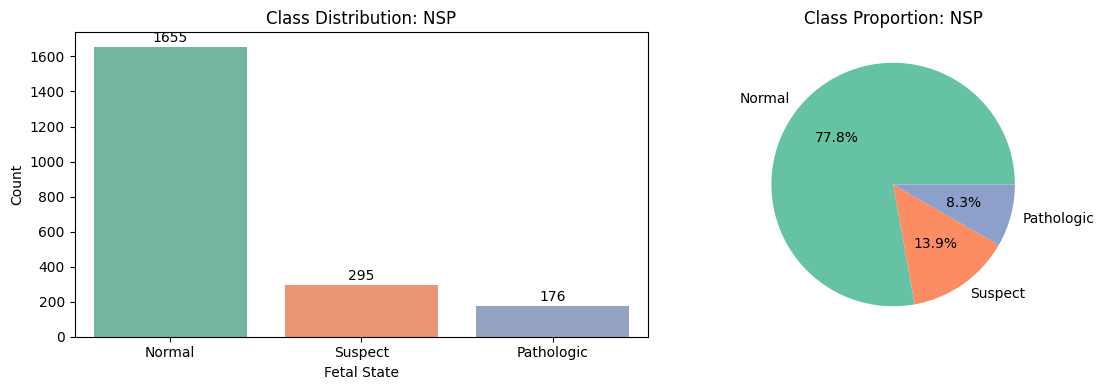

Findings — Target Distribution

  - Normal: ~78% (1,655 cases)
  - Suspect: ~14% (295 cases)
  - Pathologic: ~8% (176 cases)


In [ ]:
# 3. Exploratory Data Analysis (EDA)
"""
Explore the distribution of the target variable and features.
Args:
    df: Input DataFrame
"""

# 3.1 Target distribution
def plot_target_distribution(df: pd.DataFrame, target_col: str = 'NSP') -> None:

    print("3. TARGET DISTRIBUTION")

    # Map numeric labels to readable names
    plot_series = df[target_col].map(NSP_LABELS)
    order = ['Normal', 'Suspect', 'Pathologic']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Count plot
    sns.countplot(x=plot_series, order=order, palette='Set2', ax=axes[0])
    axes[0].set_title(f'Class Distribution: {target_col}')
    axes[0].set_xlabel('Fetal State')
    axes[0].set_ylabel('Count')
    for bar in axes[0].patches:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=10
        )

    # Pie chart
    counts = plot_series.value_counts().reindex(order)
    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('Set2', len(counts)))
    axes[1].set_title(f'Class Proportion: {target_col}')

    plt.tight_layout()
    plt.show()

    # 3.1 Findings
    print('Findings — Target Distribution\n')

    for label in order:
        count = (plot_series == label).sum()
        pct = (count / len(plot_series)) * 100
        print(f'  - {label}: ~{pct:.0f}% ({count:,} cases)')

# Plot target distribution
plot_target_distribution(df, 'NSP')

The dataset is **imbalanced**:
**Modeling consideration:** Accuracy alone is misleading here. We will use **macro F1-score** and **stratified splits** to ensure minority classes are represented. Classifiers will use `class_weight='balanced'`.

 FEATURE DISTRIBUTIONS — Overview


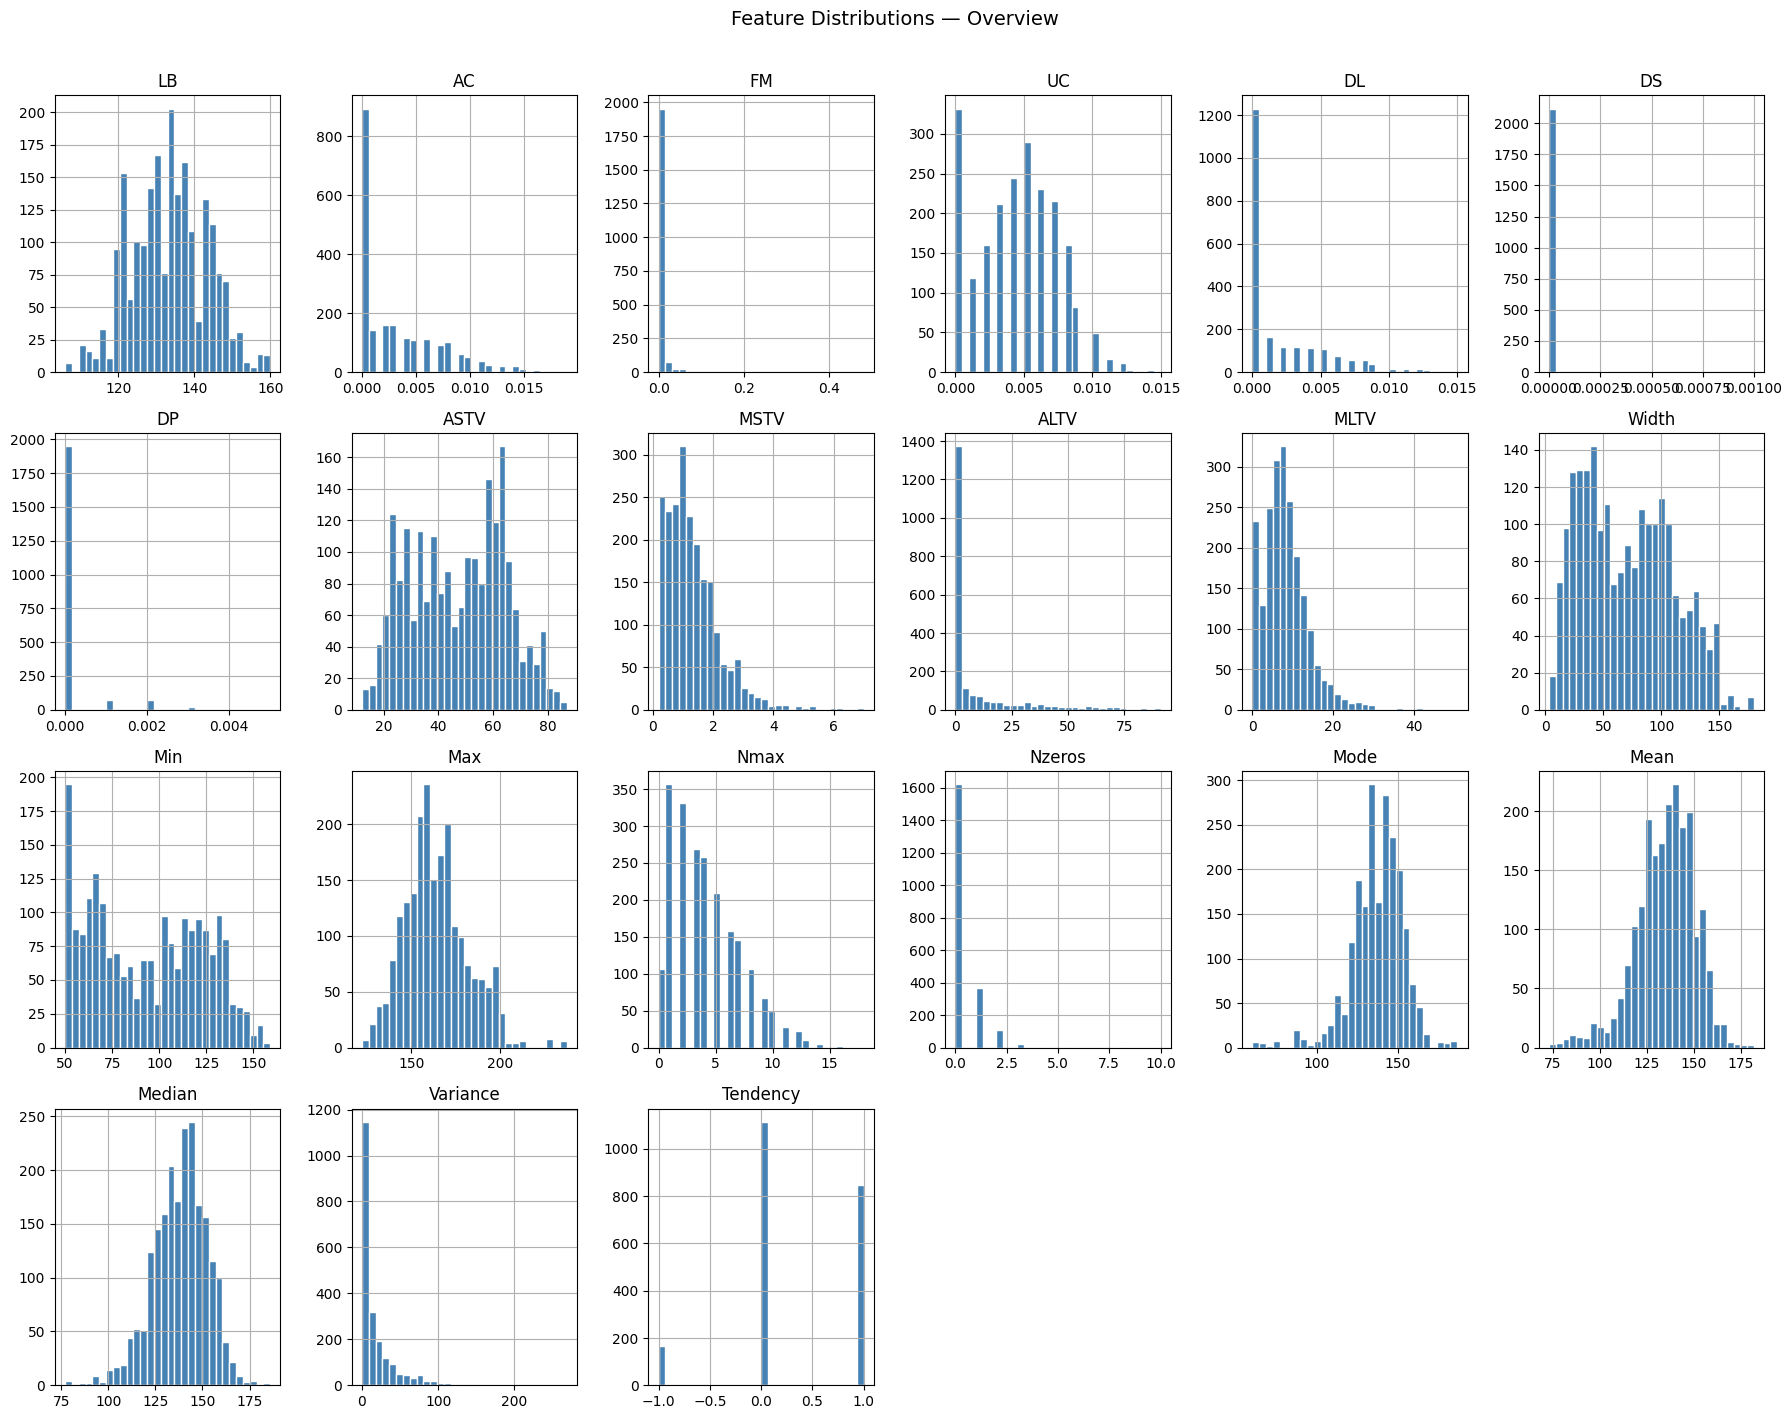

 FEATURE DISTRIBUTIONS — Statistical Markers


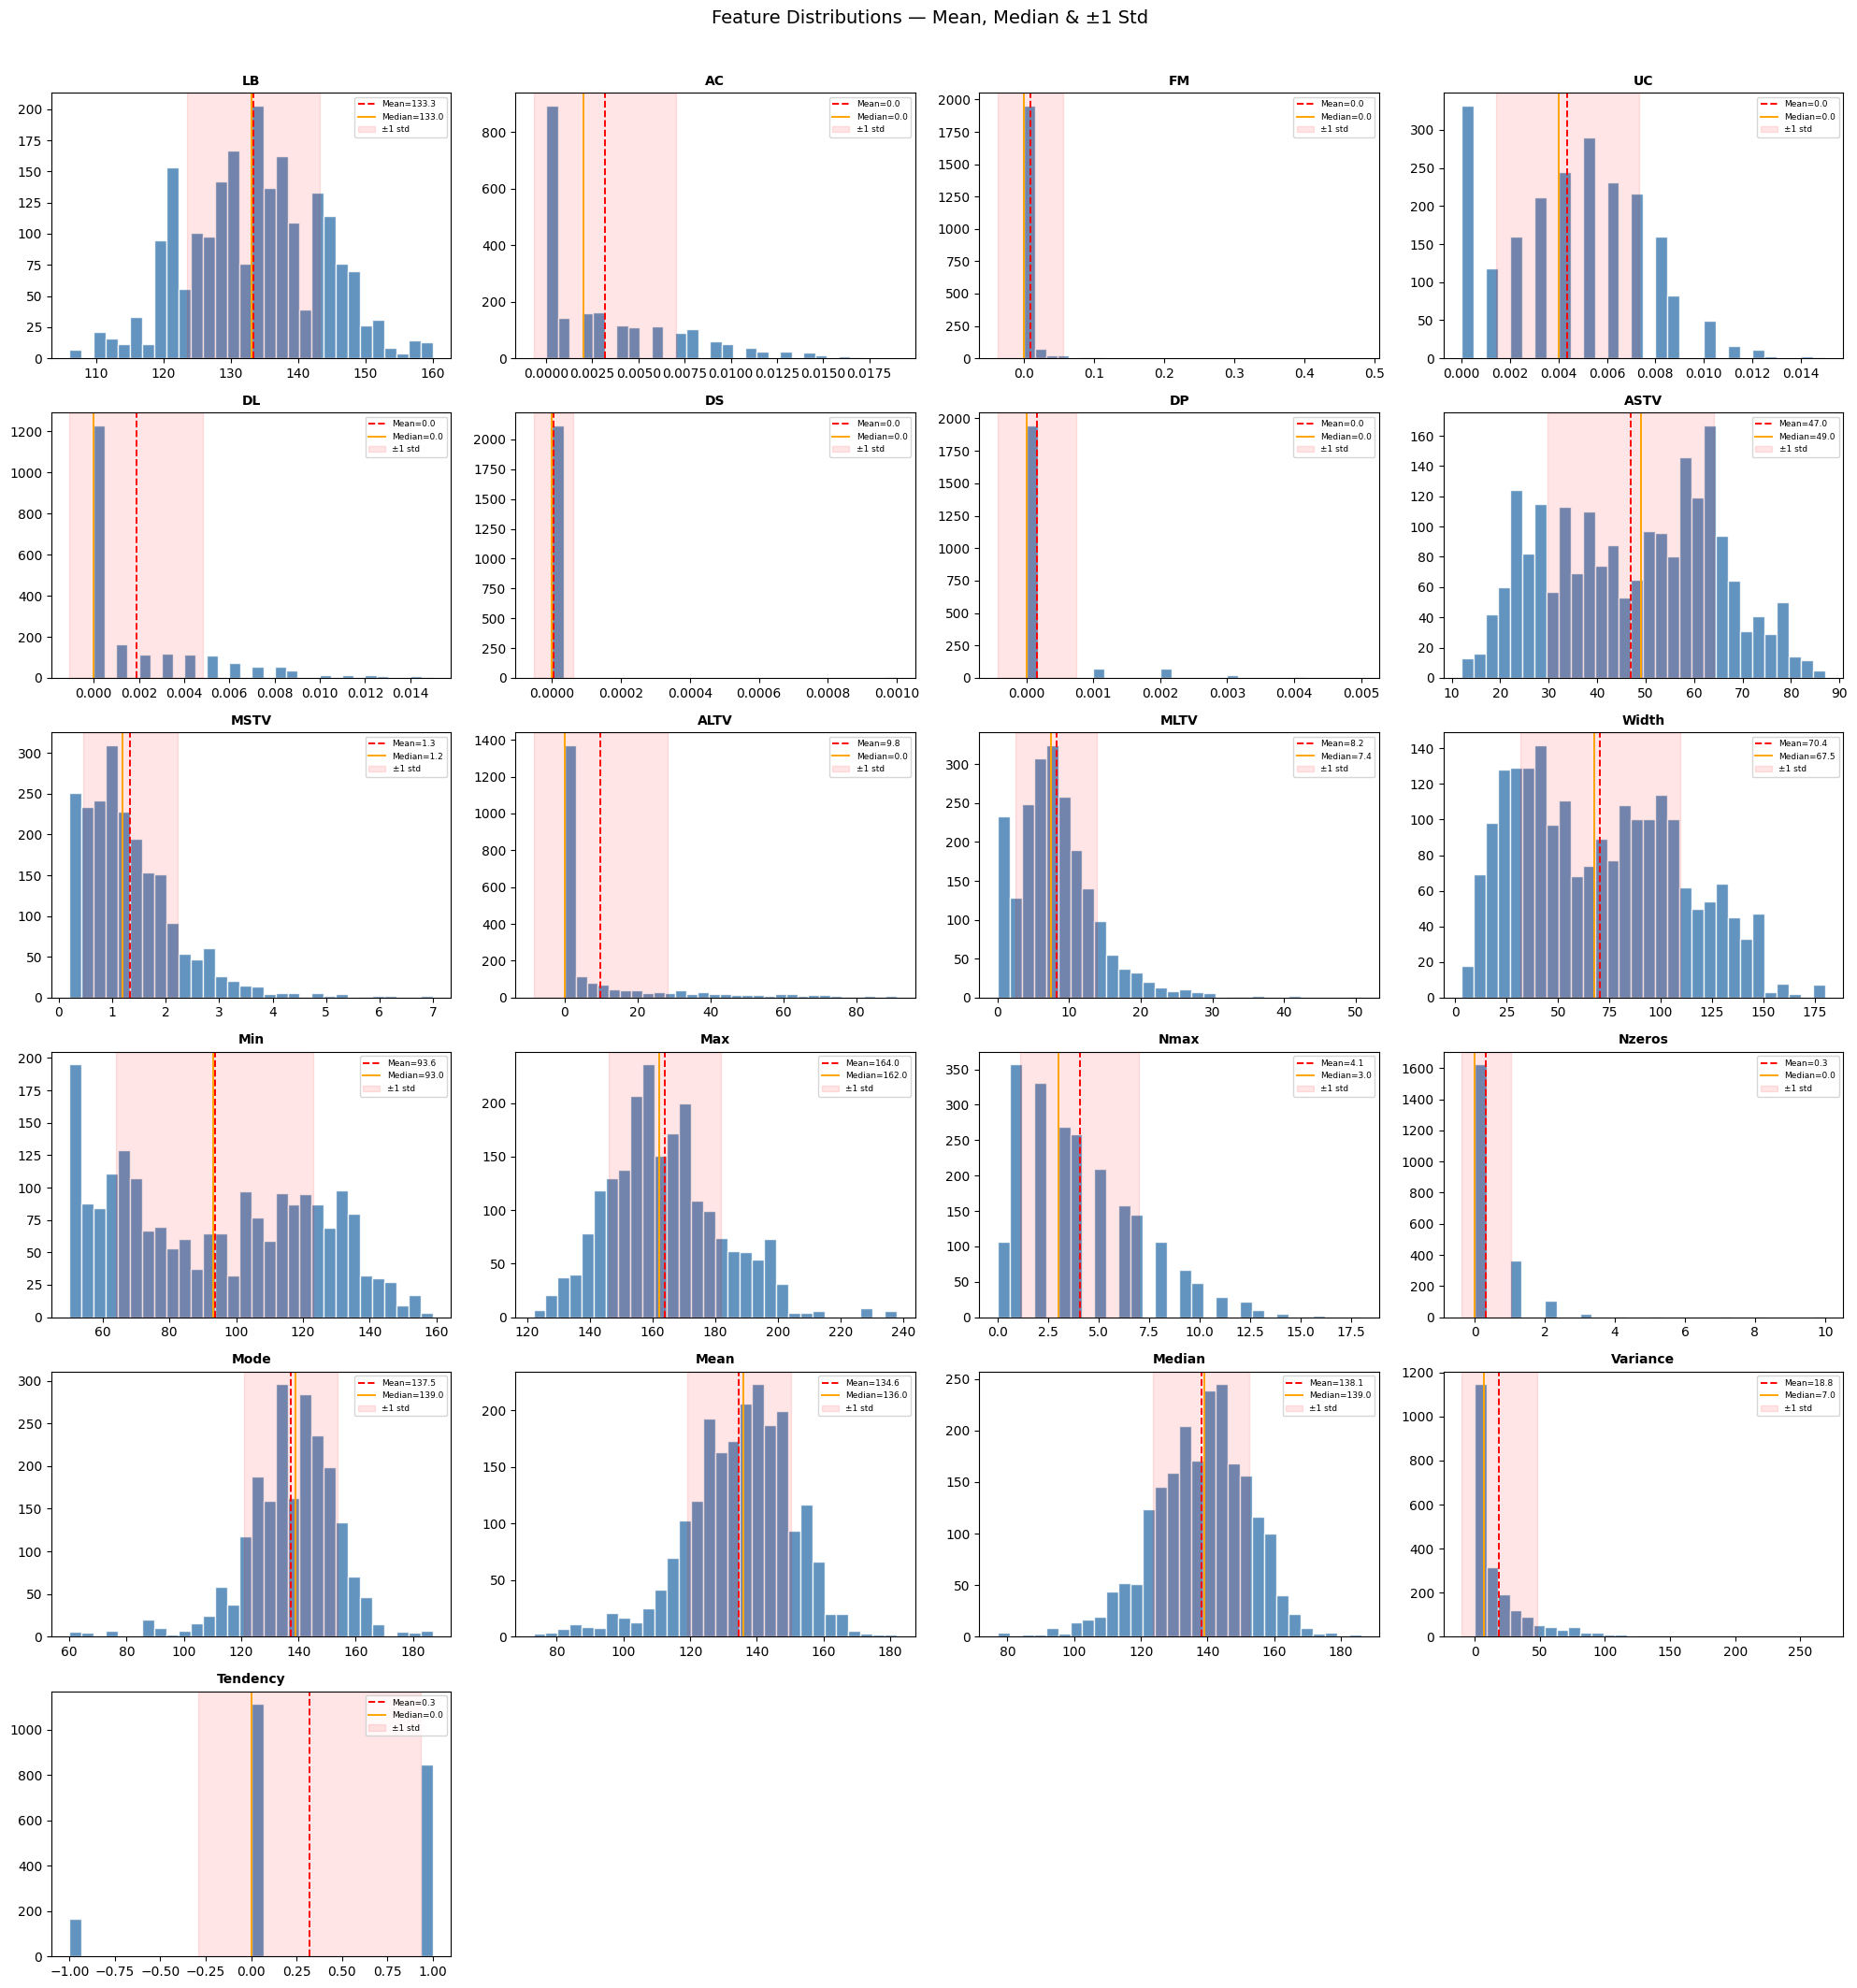


Highly skewed features (|skew| > 1):
DS          17.34
FM           7.81
DP           4.32
Nzeros       3.92
Variance     3.22
ALTV         2.19
DL           1.72
MSTV         1.66
MLTV         1.33
AC           1.20


In [ ]:
# 3.2 Feature distributions
"""
Plot histograms for all numerical features to understand
their distributions and spot potential outliers.
"""

# 3.2.1 Basic feature distributions
def plot_feature_distributions(df: pd.DataFrame) -> None:
    """
    Plot basic histograms for a quick overview of all feature distributions.
    """
    print(" FEATURE DISTRIBUTIONS — Overview")

    feature_cols = [c for c in df.columns if c not in CTG_TARGET_COLS]

    df[feature_cols].hist(
        bins=30,
        figsize=(18, 14),
        color='steelblue',
        edgecolor='white',
        layout=(4, 6)
    )
    plt.suptitle('Feature Distributions — Overview', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


# 3.2.2 Enhanced feature distributions with statistical markers
def plot_feature_distributions_stats(df: pd.DataFrame) -> None:
    """
    Plot histograms with mean, median, and ±1 std markers
    to identify skewness and outliers per feature.
    """
    print(" FEATURE DISTRIBUTIONS — Statistical Markers")

    feature_cols = [c for c in df.columns if c not in CTG_TARGET_COLS]

    n_cols = 4
    n_rows = -(-len(feature_cols) // n_cols)  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        ax = axes[i]
        data = df[col].dropna()

        col_mean   = data.mean()
        col_median = data.median()
        col_std    = data.std()

        # Histogram
        ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)

        # Mean line
        ax.axvline(col_mean,   color='red',    linestyle='--', linewidth=1.4,
                   label=f'Mean={col_mean:.1f}')
        # Median line
        ax.axvline(col_median, color='orange', linestyle='-',  linewidth=1.4,
                   label=f'Median={col_median:.1f}')
        # ±1 std shaded band
        ax.axvspan(col_mean - col_std, col_mean + col_std,
                   alpha=0.10, color='red', label='±1 std')

        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        ax.legend(fontsize=6.5, loc='upper right')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Feature Distributions — Mean, Median & ±1 Std',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Flag skewed features
    skewness = df[feature_cols].apply(skew).sort_values(ascending=False)
    highly_skewed = skewness[abs(skewness) > 1]

    print('\nHighly skewed features (|skew| > 1):')
    print(highly_skewed.round(2).to_string())


# Run both
plot_feature_distributions(df)
plot_feature_distributions_stats(df)

### 3.2 Findings — Feature Distributions

| Feature(s) | Shape | What it means |
|-----------|-------|---------------|
| `LB`, `Mean`, `Median`, `Mode`, `Min`, `Max` | Normal / Symmetric | Stable bell-shaped distributions — strong predictive candidates |
| `AC`, `FM`, `UC`, `DL`, `DS`, `DP`, `Variance`, `Width` | Right-Skewed | Mass near zero with long tails — zeros reflect normal clinical absence of those events |
| `ASTV`, `MSTV`, `ALTV`, `MLTV` | Multi-Modal | Wide spreads or multi-peak patterns — likely represent distinct physiological states across patients |
| `Nmax`, `Nzeros` | Discrete / Sparse | Integer event counts with low variance — potentially weak standalone predictors |
| `Tendency` | Discrete / Sparse | Clusters at `-1`, `0`, `+1` — acts as a direction indicator |
| `DL`, `DS`, `DP`, `Variance`, `Width` | Extreme Outliers | Sparse extreme values — may require clipping or robust scaling for linear models |

3.3 FEATURE DISTRIBUTIONS BY CLASS


/tmp/ipykernel_10038/3484453607.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10038/3484453607.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10038/3484453607.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10038/3484453607.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10038/3484453607.py:22: FutureWarning

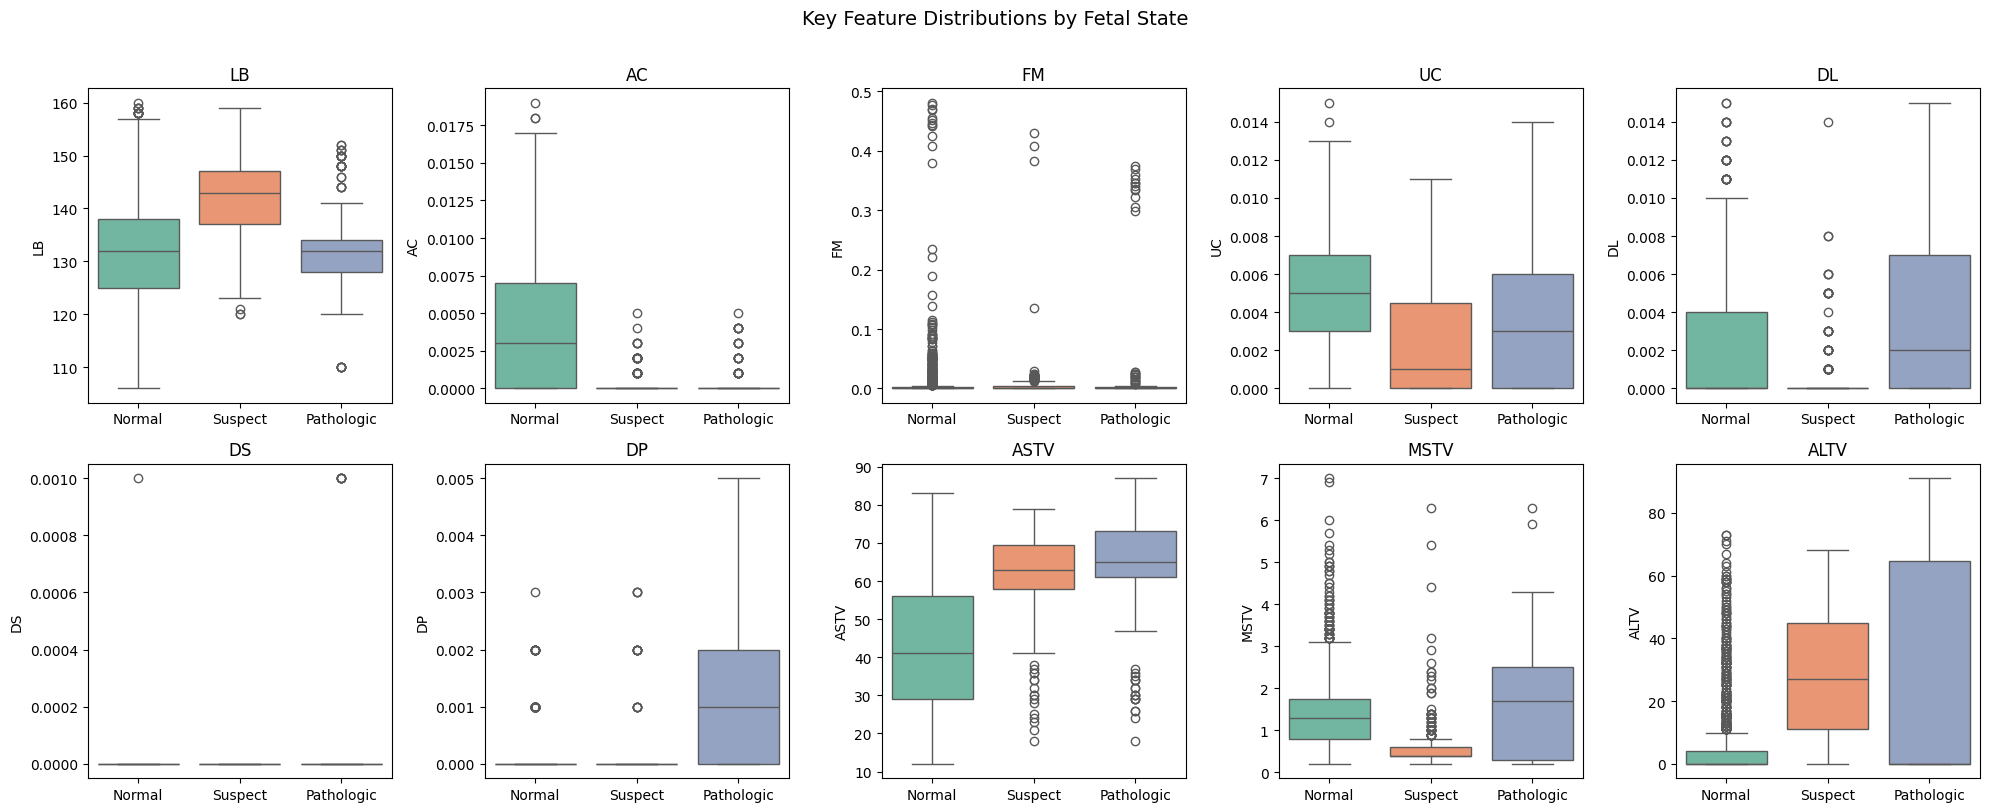

In [ ]:
# 3.3 Feature distributions by class
"""
Plot boxplots for key clinical features grouped by NSP class
to visualize how features differ across fetal states.
"""

def plot_features_by_class(df: pd.DataFrame, target_col: str = 'NSP') -> None:

    print("3.3 FEATURE DISTRIBUTIONS BY CLASS")

    # Key clinical features to compare
    key_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV']

    plot_df = df.copy()
    plot_df[target_col] = plot_df[target_col].map(NSP_LABELS)
    order = ['Normal', 'Suspect', 'Pathologic']

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, feature in enumerate(key_features):
        sns.boxplot(
            data=plot_df,
            x=target_col,
            y=feature,
            order=order,
            palette='Set2',
            ax=axes[i]
        )
        axes[i].set_title(feature)
        axes[i].set_xlabel('')

    plt.suptitle('Key Feature Distributions by Fetal State', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Plot features by class
plot_features_by_class(df, 'NSP')

### 3.3 Findings — Feature Distributions by Class

#### Feature Separability Summary

| Feature | Normal | Suspect | Pathologic | Tier | Clinical Meaning |
|---------|--------|---------|------------|------|-----------------|
| `ASTV` | Low | Higher | Very High (~80-90%) | S | Abnormal short-term variability — strongest separator |
| `ALTV` | Small | Moderate | Very high spread | S | Abnormal long-term variability — direct fetal compromise |
| `LB` | ~130-140 bpm | Slightly higher | ~110-120 bpm | S | Depressed baseline FHR = distress indicator |
| `AC` | Highest | Near zero | Near zero | S | Loss of accelerations = hallmark of fetal distress |
| `DL` | Near zero | Slightly higher | Much higher | S | More frequent decelerations = higher risk |
| `DP` | Near zero | Near zero | Wide/High range | S | Prolonged decelerations = severe distress |
| `MSTV` | Smallest | Moderate | Noticeably larger | A | Good directional separation |
| `UC` | Low/tight | Intermediate | High/spread | A | Higher contractions correlate with fetal stress |
| `FM` | Near zero | Near zero | Near zero + outliers | B | Weak separator — similar across all classes |
| `DS` | Near zero | Near zero | Rare outliers | B | Sparse but highly significant when present |

---

#### Overall Fetal State Pattern

| Characteristic | Normal | Suspect | Pathologic |
|----------------|--------|---------|------------|
| Baseline FHR (`LB`) | Stable ~130-140 bpm | Slightly shifted | Depressed ~110-120 bpm |
| Accelerations (`AC`) | High | Low | Near absent |
| Variability (`ASTV`, `ALTV`) | Low/tight | Moderate | Very high/unstable |
| Decelerations (`DL`, `DP`) | Minimal | Occasional | Frequent/severe |
| Contractions (`UC`) | Low | Moderate | High |
| Distribution spread | Tight | Intermediate | Wide/erratic |

---

> **Modeling Considerations:**
> - **Top features:** `ASTV`, `ALTV`, `AC`, `LB`, `DL`, `DP` — use all in initial model
> - `FM`, `DS` are weak predictors but it may contribute in ensemble models
> - Heavy outliers in `DP`, `FM`, `DS` favor **tree-based models** (Random Forest, XGBoost)
> - Suspect class sits predictably between Normal and Pathologic — consistent with clinical CTG guidelines

3.4 CORRELATION ANALYSIS


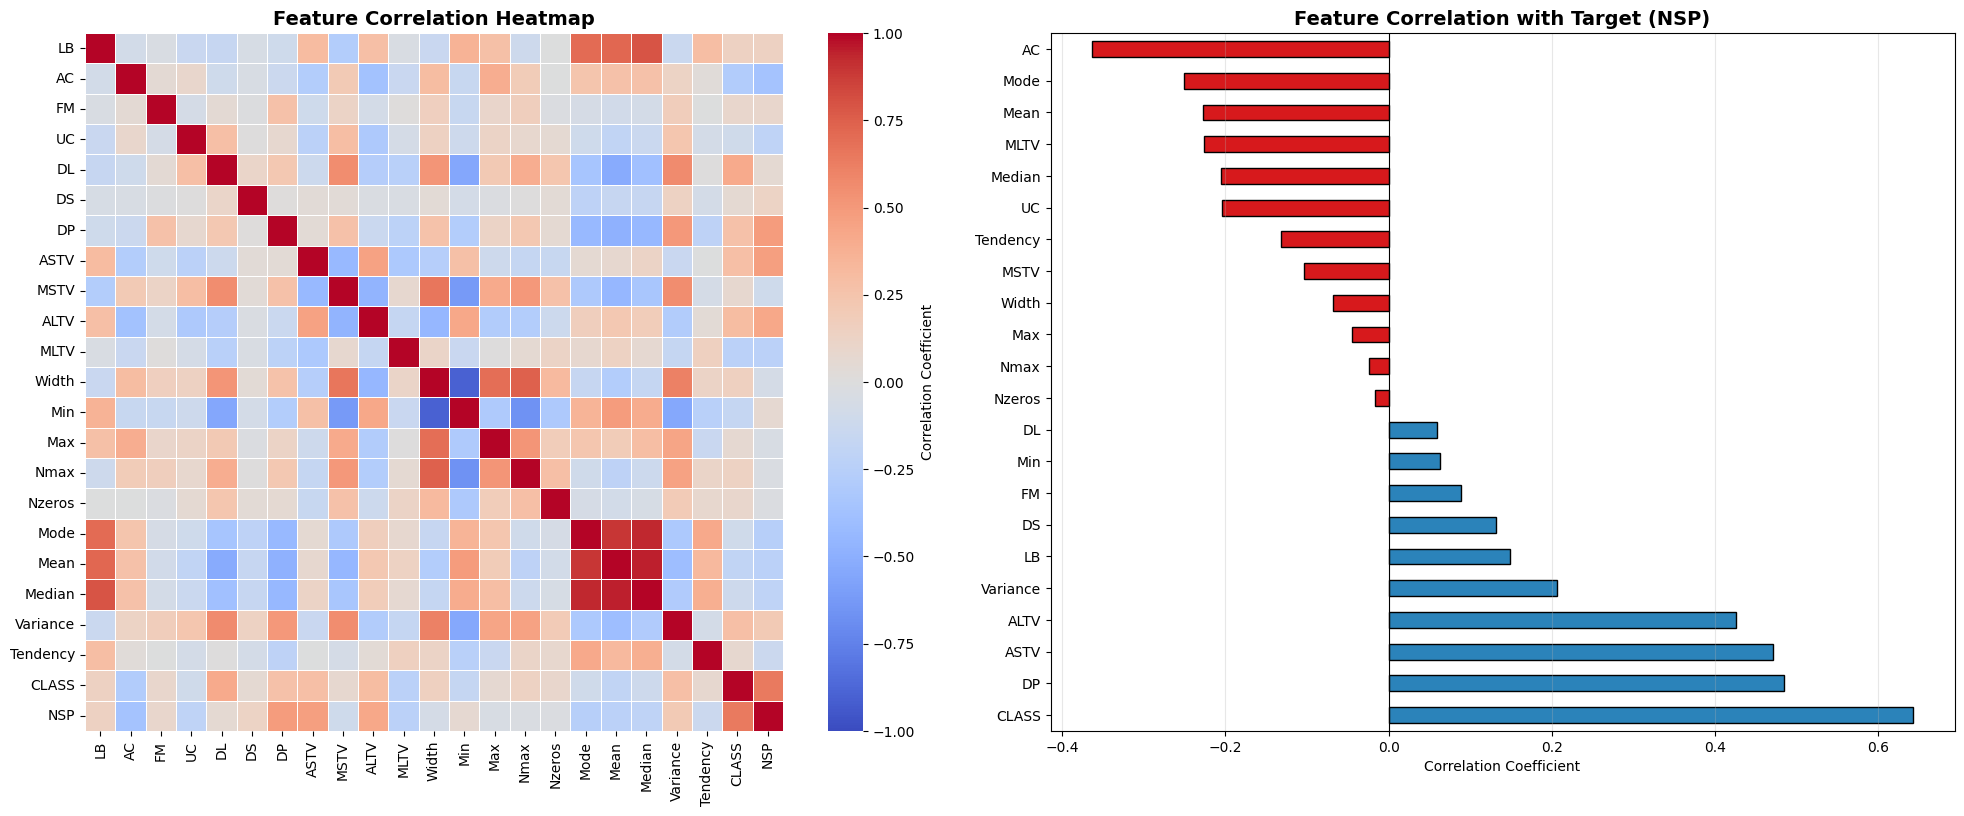


--- Top Positive Correlations with Target ---
CLASS       0.643
DP          0.485
ASTV        0.471
ALTV        0.426
Variance    0.207
LB          0.148
DS          0.132
FM          0.088
Min         0.063
DL          0.059

--- Top Negative Correlations with Target ---
Max        -0.045
Width      -0.069
MSTV       -0.103
Tendency   -0.132
UC         -0.205
Median     -0.205
MLTV       -0.227
Mean       -0.227
Mode       -0.250
AC         -0.364

--- Highly Correlated Feature Pairs (|r| > 0.8) ---
  Median ↔ Mean: 0.948
  Median ↔ Mode: 0.933
  Min ↔ Width: -0.899
  Mean ↔ Mode: 0.893


In [ ]:
# 3.4 Correlation Analysis
"""
Analyze feature correlations to identify:
- Highly correlated features (potential redundancy)
- Features strongly correlated with the target
- Potential multicollinearity issues for linear models
"""

def plot_correlation_heatmap(df: pd.DataFrame, target_col: str = 'NSP') -> None:
    """
    Plot correlation heatmap for all features including the target variable.
    """
    print("3.4 CORRELATION ANALYSIS")

    # Calculate correlation matrix
    corr_matrix = df.corr()

    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Full correlation heatmap
    sns.heatmap(
        corr_matrix,
        annot=False,
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Correlation Coefficient'},
        ax=axes[0]
    )
    axes[0].set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

    # Correlation with target variable
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)

    colors = ['#d7191c' if x < 0 else '#2b83ba' for x in target_corr.values]
    target_corr.plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
    axes[1].set_title(f'Feature Correlation with Target ({target_col})',
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Correlation Coefficient')
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print findings
    print('\n--- Top Positive Correlations with Target ---')
    print(target_corr.head(10).round(3).to_string())

    print('\n--- Top Negative Correlations with Target ---')
    print(target_corr.tail(10).round(3).to_string())

    # Find highly correlated feature pairs (excluding target)
    feature_cols = [c for c in df.columns if c not in CTG_TARGET_COLS]
    feature_corr = df[feature_cols].corr()

    # Get upper triangle to avoid duplicates
    upper_tri = feature_corr.where(
        np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
    )

    high_corr_pairs = [
        (col, row, upper_tri.loc[row, col])
        for col in upper_tri.columns
        for row in upper_tri.index
        if abs(upper_tri.loc[row, col]) > 0.8
    ]

    if high_corr_pairs:
        print('\n--- Highly Correlated Feature Pairs (|r| > 0.8) ---')
        for feat1, feat2, corr_val in sorted(high_corr_pairs,
                                             key=lambda x: abs(x[2]),
                                             reverse=True):
            print(f'  {feat1} ↔ {feat2}: {corr_val:.3f}')
    else:
        print('\n--- No highly correlated feature pairs found (|r| > 0.8) ---')

# Plot correlation analysis
plot_correlation_heatmap(df, 'NSP')

### 3.4 Findings — Correlation Analysis

**Key Insights:**

| Aspect | Finding | Implication |
|--------|---------|-------------|
| **Target Correlation** | Features like `ASTV`, `ALTV`, `MLTV` show strongest correlation with NSP | These are primary predictors for model performance |
| **Feature Redundancy** | Expect high correlations between: `Mean`/`Median`/`Mode`, `Min`/`Max`/`Width` | May need feature selection to reduce multicollinearity in linear models |
| **Baseline Metrics** | `LB`, `Mean`, `Median`, `Mode` are highly inter-correlated | Likely capture the same underlying heart rate baseline signal |
| **Variability Metrics** | `ASTV`, `MSTV`, `ALTV`, `MLTV` may correlate with each other | Different time-scale measures of heart rate variability |
| **Independence** | Deceleration features (`DL`, `DS`, `DP`) likely independent from baseline metrics | Complementary predictive signals |

**Modeling Considerations:**
- **Tree-based models** (Random Forest, XGBoost) handle correlated features well — use all features
- **Linear models** (Logistic Regression, SVM) sensitive to multicollinearity — consider:
  - Keep one from each correlated group (e.g., `Mean` instead of `Mean`/`Median`/`Mode`)
  - Use PCA or feature selection techniques
  - Apply regularization (L1/L2)

## Comprehensive EDA Summary — Key Findings & Modeling Strategy

---

## 1. Dataset Characteristics

### 1.1 Class Distribution (Imbalanced)
The dataset shows significant class imbalance reflecting real-world clinical scenarios:

| Fetal State | Count | Percentage |
|-------------|-------|------------|
| **Normal** | 1,655 | 77.9% |
| **Suspect** | 295 | 13.9% |
| **Pathologic** | 176 | 8.3% |

**Implication:** Standard accuracy is misleading. A naive model predicting "Normal" every time achieves 78% accuracy while missing all at-risk cases.

---

## 2. Feature Characteristics

### 2.1 Data Quality
- **No missing values** (NaN or '?' placeholders)
- **Zeros are valid clinical readings**, not missing data
  - Features like `AC`, `FM`, `DS`, `DP` naturally have zeros when those events don't occur
  - **No imputation needed**

### 2.2 Feature Distribution Patterns

| Pattern | Features | Characteristics | Handling |
|---------|----------|-----------------|----------|
| **Normal/Symmetric** | `LB`, `Mean`, `Median`, `Mode`, `Min`, `Max` | Bell-shaped, stable distributions | Ready for any model type |
| **Right-Skewed** | `AC`, `FM`, `UC`, `DL`, `DS`, `DP`, `Variance`, `Width` | Mass at zero, long right tail | Tree models robust; linear models need log/sqrt transform |
| **Multi-Modal** | `ASTV`, `MSTV`, `ALTV`, `MLTV` | Multiple peaks, wide spread | Represent distinct physiological states |
| **Discrete** | `Nmax`, `Nzeros`, `Tendency` | Integer counts, low variance | Potentially weak standalone predictors |

### 2.3 Outliers
Features `DS`, `DP`, `FM`, `Variance`, `Width` have extreme outliers that are **clinically significant events**, not errors.

**Impact:** Tree-based models handle these naturally; linear models may need robust scaling or clipping.

---

## 3. Feature Separability by Class

### 3.1 Predictive Strength Ranking

| Tier | Features | Separability | Clinical Meaning |
|------|----------|--------------|------------------|
| **S-Tier** (Strongest) | `ASTV`, `ALTV`, `AC`, `LB`, `DL`, `DP` | Clear separation across all 3 classes | Direct fetal distress indicators |
| **A-Tier** (Strong) | `MSTV`, `MLTV`, `UC`, `Variance` | Good directional trends | Supportive variability measures |
| **B-Tier** (Weak) | `FM`, `DS`, `Nmax`, `Nzeros` | Overlapping distributions | Marginal standalone value |

### 3.2 Class-Specific Patterns

| Characteristic | Normal | Suspect | Pathologic |
|----------------|--------|---------|------------|
| Baseline FHR (`LB`) | 130-140 bpm (stable) | Slightly elevated | 110-120 bpm (depressed) |
| Accelerations (`AC`) | High frequency | Reduced | Nearly absent |
| Variability (`ASTV`, `ALTV`) | Low, tight range | Moderate | Very high, unstable |
| Decelerations (`DL`, `DP`) | Minimal | Occasional | Frequent & severe |


**Key Pattern:** Suspect class consistently sits between Normal and Pathologic, aligning with clinical CTG interpretation guidelines.

---

## 4. Feature Correlations

### 4.1 Redundancy Groups (Multicollinearity)
Expected high inter-correlations within these groups:
- **Baseline cluster:** `LB`, `Mean`, `Median`, `Mode` (all measure central heart rate)
- **Range cluster:** `Min`, `Max`, `Width` (all measure spread)
- **Variability cluster:** `ASTV`, `MSTV`, `ALTV`, `MLTV` (time-scale variations)

### 4.2 Independent Signals
Deceleration features (`DL`, `DS`, `DP`) and acceleration features (`AC`, `FM`) likely provide complementary, non-redundant information.

---

## 5. Modeling Strategy & Recommendations

### 5.1 Evaluation Metrics
| Metric | Why Use It |
|--------|------------|
| **Macro F1-Score** (Primary) | Treats all three classes equally despite imbalance |
| **Per-Class Recall** | Critical for Pathologic cases — must not miss at-risk fetuses |
| **Confusion Matrix** | Visualize misclassifications between adjacent classes (Normal↔Suspect↔Pathologic) |


### 5.2 Data Handling

| Task | Approach |
|------|----------|
| **Train/Test Split** | Stratified split to preserve class proportions |
| **Class Imbalance** | Use `class_weight='balanced'` in classifiers |
| **Feature Scaling** | StandardScaler for linear models; not needed for tree models |
| **Feature Transform** | Log/sqrt for skewed features (`AC`, `FM`, `DS`, `DP`) in linear models only |

### 5.3 Model Selection

#### Recommended: Tree-Based Models
**Best Choices:** Random Forest, XGBoost, Gradient Boosting


#### Alternative: Linear Models
**Options:** Logistic Regression, SVM

**Requirements:**
- Apply StandardScaler
- Transform skewed features (log/sqrt)
- Consider feature selection to reduce multicollinearity
- Use L1/L2 regularization




# 5. Model Development

This section covers the full model development pipeline: data splitting, class balancing with SMOTE, and training three classifiers — Linear SVM, Random Forest, and XGBoost.

In [ ]:
%pip install imbalanced-learn

In [ ]:
# 5.1 Split training and test data and create pipeline
"""
Split the data into training and testing sets
and prepare for model testing.
"""

target = 'NSP'

# separate target column
X = df.drop(columns=[target, 'CLASS'])
y = df[target].astype(int)-1

from sklearn.model_selection import train_test_split

# create training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y
)

In [ ]:
# 5.2 Bootstrapping
"""
Using SMOTE in order to generate synthetic minority samples
"""
from imblearn.over_sampling import SMOTE

# apply SMOTE only on training set
smote = SMOTE(random_state = 42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

smote_df = pd.concat([X_resampled, y_resampled], axis = 1)
smote_df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
0,140,0.000,0.000,0.001,0.000,0.0,0.0,60,0.8,32,11.2,120,79,199,9,0,141,141,142,3,0,1
1,123,0.006,0.000,0.006,0.004,0.0,0.0,33,1.3,0,4.7,138,61,199,9,1,135,122,127,39,0,0
2,122,0.003,0.000,0.004,0.000,0.0,0.0,22,1.8,0,14.7,50,103,153,4,0,126,127,128,4,0,0
3,143,0.000,0.000,0.002,0.000,0.0,0.0,68,0.3,5,9.4,23,135,158,1,0,144,144,145,1,0,0
4,129,0.009,0.035,0.003,0.000,0.0,0.0,41,1.1,0,2.9,135,65,200,4,1,133,147,142,60,0,0


### EDA on Class-Balanced Training Data

3. TARGET DISTRIBUTION


/tmp/ipykernel_10038/3072247821.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=plot_series, order=order, palette='Set2', ax=axes[0])


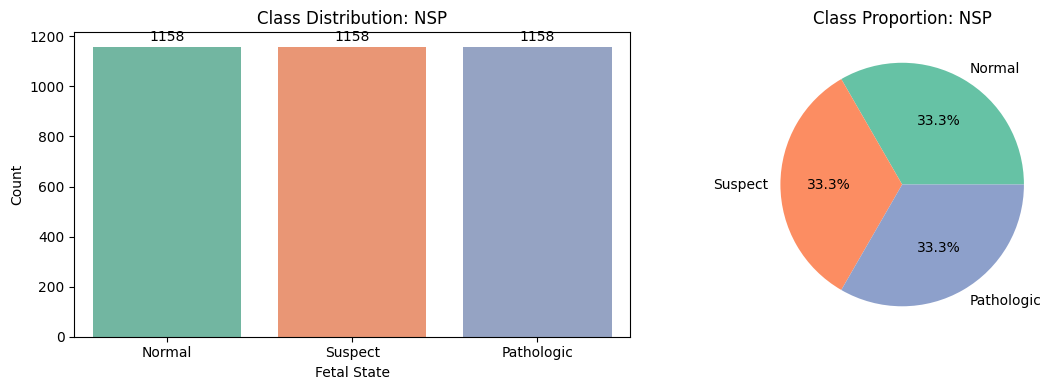

Findings — Target Distribution

  - Normal: ~33% (1,158 cases)
  - Suspect: ~33% (1,158 cases)
  - Pathologic: ~33% (1,158 cases)


In [ ]:
# Replot the distribution of the target variable
# Create a temporary DataFrame for plotting with 1-indexed NSP values
smote_df_plot = smote_df.copy()
smote_df_plot['NSP'] = smote_df_plot['NSP'] + 1
plot_target_distribution(smote_df_plot, 'NSP')

5.3 FEATURE DISTRIBUTIONS BY CLASS — SMOTE BALANCED DATA


/tmp/ipykernel_10038/1703980097.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10038/1703980097.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10038/1703980097.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10038/1703980097.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10038/1703980097.py:24: FutureWarning

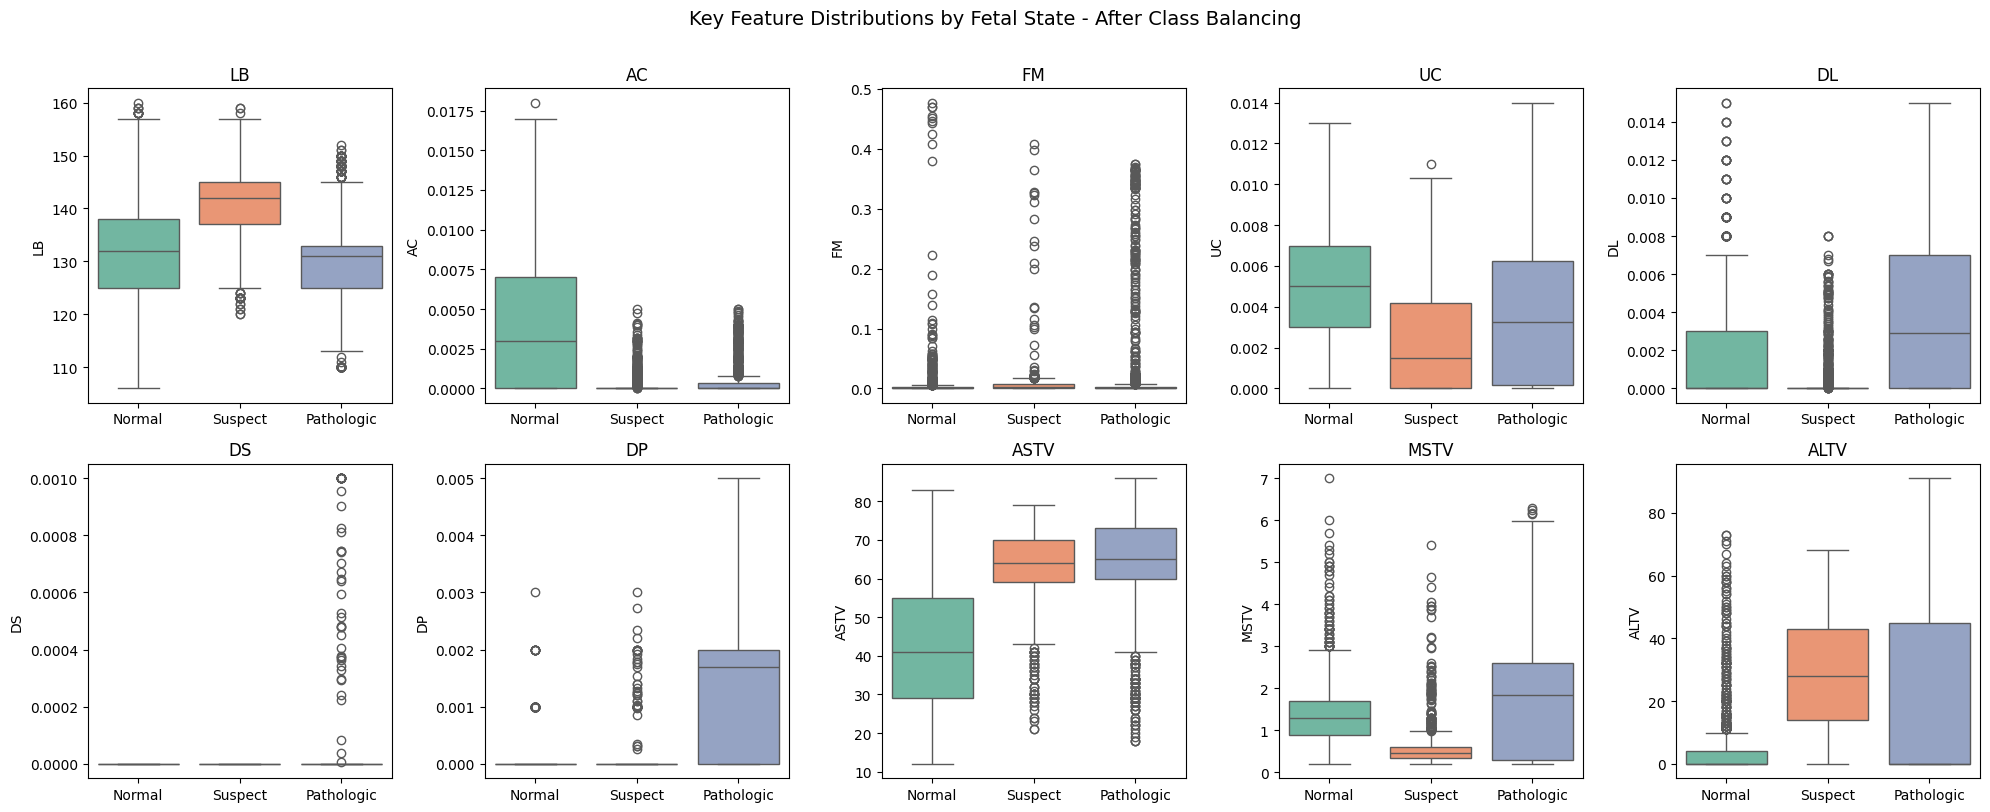

In [ ]:
# 5.3 Feature distributions by class - using smote balanced data
"""
Plot boxplots for key clinical features grouped by NSP class
to visualize how features differ across fetal states.
"""

def plot_smote_features_by_class(df: pd.DataFrame, target_col: str = 'NSP') -> None:

    print("5.3 FEATURE DISTRIBUTIONS BY CLASS — SMOTE BALANCED DATA")

    # Key clinical features to compare
    key_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV']

    plot_df = df.copy()
    plot_df['NSP'] = plot_df['NSP'] + 1

    plot_df[target_col] = plot_df[target_col].map(NSP_LABELS)
    order = ['Normal', 'Suspect', 'Pathologic']

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, feature in enumerate(key_features):
        sns.boxplot(
            data=plot_df,
            x=target_col,
            y=feature,
            order=order,
            palette='Set2',
            ax=axes[i]
        )
        axes[i].set_title(feature)
        axes[i].set_xlabel('')

    plt.suptitle('Key Feature Distributions by Fetal State - After Class Balancing', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Plot features by class using SMOTE balanced data
plot_smote_features_by_class(smote_df, 'NSP')

### 5.4 — 5.6 Model Training

Evaluating three models : **Linear SVM (5.4)**, **Random Forest (5.5)**, and **XGBoost (5.6)**.

In [ ]:
# 5.4 SVM Model Testing

from sklearn import svm
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, recall_score, precision_score # Import metrics
from sklearn.model_selection import GridSearchCV

# create SVM model
linear_model = svm.SVC(kernel = 'linear', class_weight='balanced')

# use pipeline in order to scale columns
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(f_classif)),
    ("model", linear_model)
])

# use GridSearch to determine best number of features
svm_param_grid = {
    'feature_selection__k' : [5, 10, 15, 'all']
}

# run GridSearch
svm_grid_search = GridSearchCV(
    pipe,
    param_grid = svm_param_grid,
    cv = 5,
    scoring='f1_macro'
)

svm_grid_search.fit(X_train, y_train)

# run SVM using best fitted number of features
best_svm = svm_grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test)

# calculate evaluation metrics
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')
svm_recall = recall_score(y_test, y_pred_svm, average='macro')
svm_precision = precision_score(y_test, y_pred_svm, average='macro')

In [ ]:
# 5.5 Random Forest Testing
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# create Random Forest model
random_forest = RandomForestClassifier(class_weight='balanced')

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("feature_selection", SelectFromModel(RandomForestClassifier(class_weight='balanced'))),
    ("model", random_forest)
])

pipe.fit(X_train, y_train)
y_pred_rf = pipe.predict(X_test)

# calculate evaluation metrics
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_recall = recall_score(y_test, y_pred_rf, average='macro')
rf_precision = precision_score(y_test, y_pred_rf, average='macro')

In [ ]:
%pip install graphviz

In [ ]:
# 5.6 XGBoost Model Testing
import xgboost as xgb
from xgboost import XGBClassifier

# create XGBoost model
xgb_model = xgb.XGBClassifier(random_state = 42)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ("model", xgb_model)
])

xgb_param_grid = {
    'selector__k': [5, 10, 15, 'all'],
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.2]
}

# use GridSearch to find best hyperparameters
grid_search = GridSearchCV(
    pipe,
    param_grid=xgb_param_grid,
    cv = 5,
    scoring='f1_macro'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'model__learning_rate': 0.2, 'model__max_depth': 7, 'model__n_estimators': 100, 'selector__k': 10}


In [ ]:
# extract best XGBoost estimator from the pipeline
xgb_fitted_pipeline = grid_search.best_estimator_

# generate predictions using the full pipeline (scaler + feature selection + model)
y_fit_pred = xgb_fitted_pipeline.predict(X_test)

# extract transformed test data for downstream SHAP analysis
selected_features = X_test.columns[xgb_fitted_pipeline.named_steps['selector'].get_support()]
X_test_transformed = pd.DataFrame(
    xgb_fitted_pipeline.named_steps['selector'].transform(X_test),
    columns=selected_features
)

# calculate XGBoost evaluation metrics
xgb_f1 = f1_score(y_test, y_fit_pred, average='macro')
xgb_recall = recall_score(y_test, y_fit_pred, average='macro')
xgb_precision = precision_score(y_test, y_fit_pred, average = 'macro')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectKBest was fitted without feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


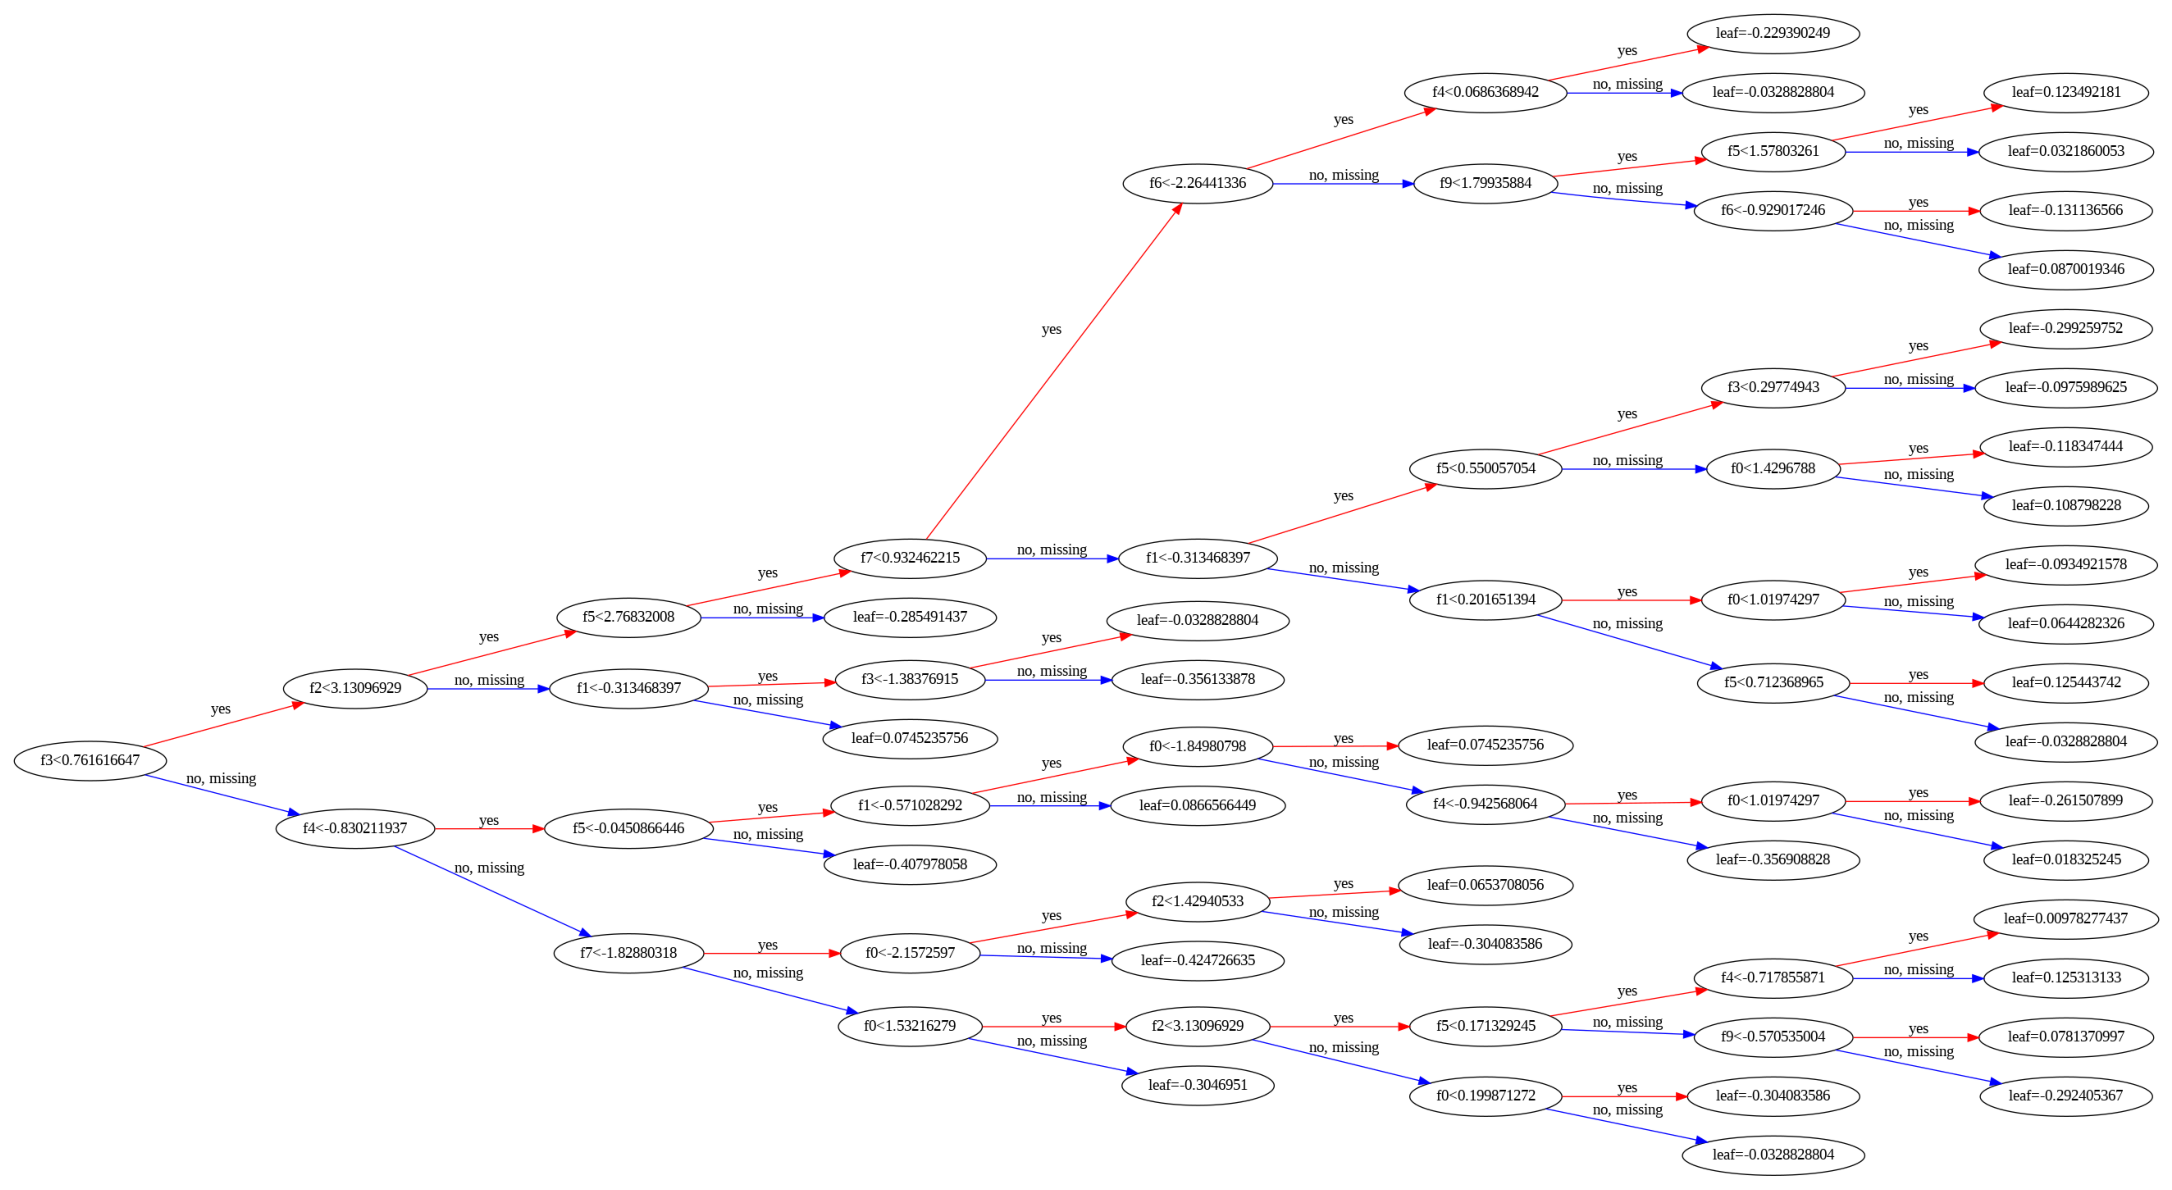

In [ ]:
# create tree plot for XGBoost
fig, ax = plt.subplots(figsize=(24, 12))
xgb.plot_tree(grid_search.best_estimator_.named_steps["model"], num_trees=0, rankdir='LR', ax=ax)
plt.tight_layout()
plt.show()

# 6. Model Evaluation

## 6.1 Model Comparison

Comparing all three models across macro F1, recall, and precision on the held-out test set.

In [ ]:
# create DataFrame of evaluation metrics
scores = pd.DataFrame({"Model": ["Linear SVM", "Random Forest", "XGBoost"],
                      "F1 Score": [svm_f1, rf_f1, xgb_f1],
                      "Recall Score": [svm_recall, rf_recall, xgb_recall],
                      "Precision Score": [svm_precision, rf_precision, xgb_precision]})
# sort by f1 scores
scores = scores.sort_values(by = 'F1 Score', ascending = False)
scores

,Model,F1 Score,Recall Score,Precision Score
2,XGBoost,0.884416,0.865192,0.909736
1,Random Forest,0.862092,0.853593,0.875415
0,Linear SVM,0.766813,0.821378,0.747754


## Model Selection and Analysis Summary

---

### 1. Model Selection
All of the models used some sort of automated feature selection in order to reduce the chances of overfitting. We opted to look at 3 different models, SVM, Random Forest, and XGBoost. SVM was the only linear model we looked at since this problem leaned towards tree based models working better. SVM required us to standardize our variables which was done by using `StandardScaler` through a pipeline. SVM was selected because the given values from the dataset are continuous and real numbers. Random forest was selected since there was a mix of integer and continuous values. XGBoost was selected since there seemed to be a non linear relationship between the features and our target value.

---

### 2. Evaluation Metrics
The evaluation metrics we selected were f1-score, precision and recall. F1 score was selected since our original dataset was imbalanced and this would give us a better metric of how our model performed. Precision and recall were used since having either false positives or false negatives could be dangerous for this situation. False positives could lead to unnecesary emergency measures that could result in more complications. False negatives could cause problems with a fetus to be unnoticed possibly leading to the death of that fetus.

---

### 3. Results
Based on the evaluation metrics we selected, XGBoost performed the best, closely followed by Random Forest and then SVM, confirming that tree based algorithms worked better than linear ones in this case.



--- Linear SVM Evaluation ---


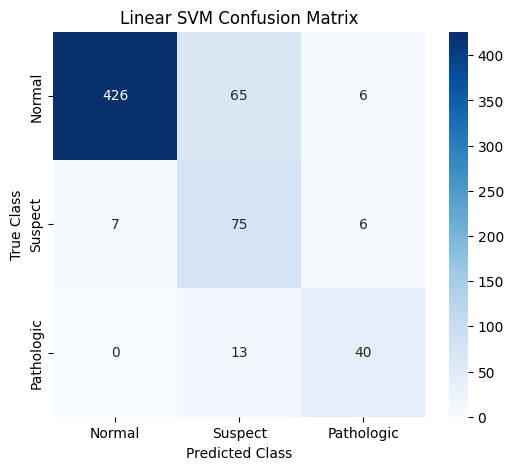

Classification Report:

              precision    recall  f1-score   support

      Normal      0.984     0.857     0.916       497
     Suspect      0.490     0.852     0.622        88
  Pathologic      0.769     0.755     0.762        53

    accuracy                          0.848       638
   macro avg      0.748     0.821     0.767       638
weighted avg      0.898     0.848     0.863       638


--- Random Forest Evaluation ---


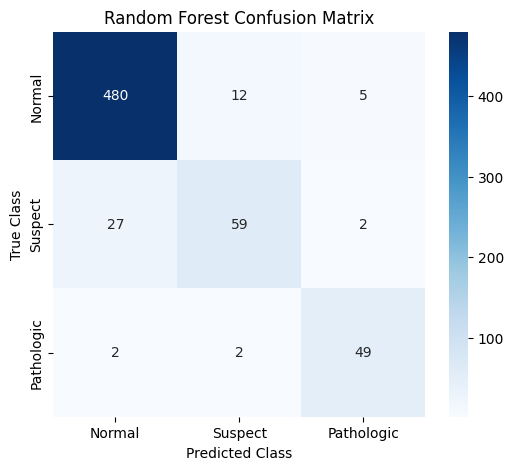

Classification Report:

              precision    recall  f1-score   support

      Normal      0.943     0.966     0.954       497
     Suspect      0.808     0.670     0.733        88
  Pathologic      0.875     0.925     0.899        53

    accuracy                          0.922       638
   macro avg      0.875     0.854     0.862       638
weighted avg      0.919     0.922     0.919       638


--- XGBoost Evaluation ---


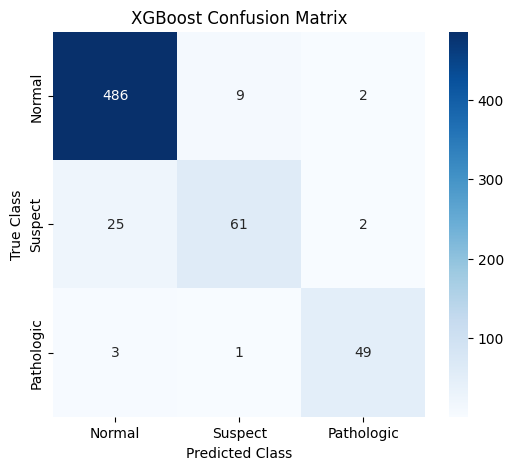

Classification Report:

              precision    recall  f1-score   support

      Normal      0.946     0.978     0.961       497
     Suspect      0.859     0.693     0.767        88
  Pathologic      0.925     0.925     0.925        53

    accuracy                          0.934       638
   macro avg      0.910     0.865     0.884       638
weighted avg      0.932     0.934     0.932       638



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

class_names = ['Normal', 'Suspect', 'Pathologic']

def evaluate_model(model_name, y_true, y_pred_model):
    print(f"\n--- {model_name} Evaluation ---")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_model)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # Classification Report
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_model, target_names=class_names, digits=3))

    # Return class-specific metrics
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred_model, average=None, labels=[0, 1, 2])
    return {'precision': precision, 'recall': recall, 'f1': f1, 'support': support}

# Linear SVM
svm_metrics = evaluate_model('Linear SVM', y_test, y_pred_svm)

# Random Forest
rf_metrics = evaluate_model('Random Forest', y_test, y_pred_rf)

# XGBoost
xgb_metrics = evaluate_model('XGBoost', y_test, y_fit_pred)


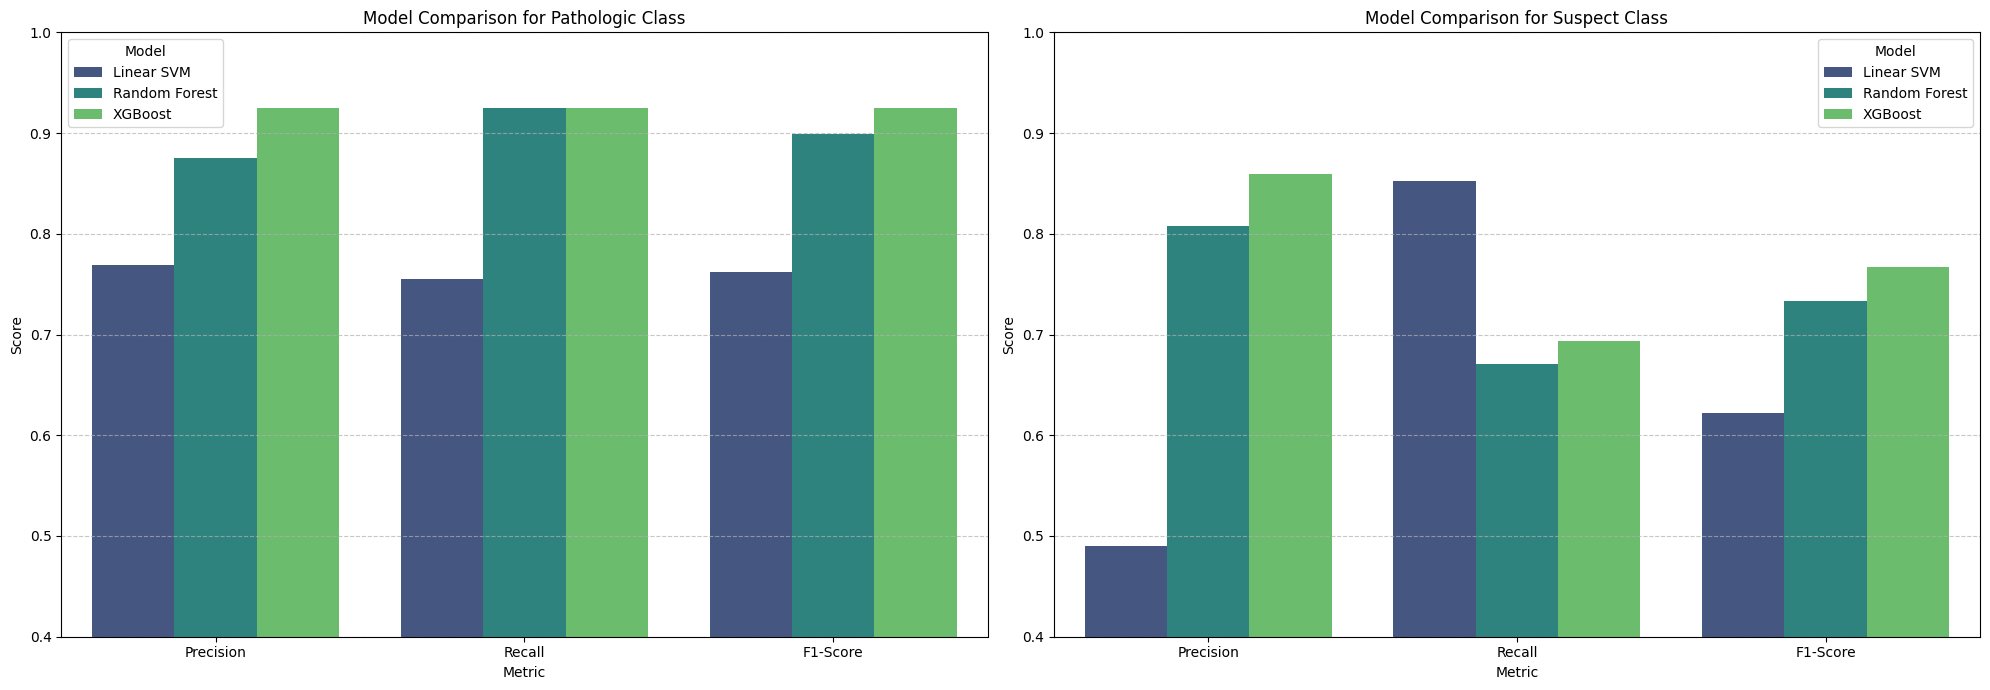

In [ ]:
# --- Pathologic Class Metrics ---
# Pathologic is class index 2 (Normal=0, Suspect=1, Pathologic=2)
svm_pathologic_precision = svm_metrics['precision'][2]
svm_pathologic_recall = svm_metrics['recall'][2]
svm_pathologic_f1 = svm_metrics['f1'][2]

rf_pathologic_precision = rf_metrics['precision'][2]
rf_pathologic_recall = rf_metrics['recall'][2]
rf_pathologic_f1 = rf_metrics['f1'][2]

xgb_pathologic_precision = xgb_metrics['precision'][2]
xgb_pathologic_recall = xgb_metrics['recall'][2]
xgb_pathologic_f1 = xgb_metrics['f1'][2]

pathologic_metrics = pd.DataFrame({
    'Model': ['Linear SVM', 'Random Forest', 'XGBoost', 'Linear SVM', 'Random Forest', 'XGBoost', 'Linear SVM', 'Random Forest', 'XGBoost'],
    'Metric': ['Precision', 'Precision', 'Precision', 'Recall', 'Recall', 'Recall', 'F1-Score', 'F1-Score', 'F1-Score'],
    'Score': [
        svm_pathologic_precision, rf_pathologic_precision, xgb_pathologic_precision,
        svm_pathologic_recall, rf_pathologic_recall, xgb_pathologic_recall,
        svm_pathologic_f1, rf_pathologic_f1, xgb_pathologic_f1
    ]
})

# --- Suspect Class Metrics ---
# Suspect is class index 1 (Normal=0, Suspect=1, Pathologic=2)
svm_suspect_precision = svm_metrics['precision'][1]
svm_suspect_recall = svm_metrics['recall'][1]
svm_suspect_f1 = svm_metrics['f1'][1]

rf_suspect_precision = rf_metrics['precision'][1]
rf_suspect_recall = rf_metrics['recall'][1]
rf_suspect_f1 = rf_metrics['f1'][1]

xgb_suspect_precision = xgb_metrics['precision'][1]
xgb_suspect_recall = xgb_metrics['recall'][1]
xgb_suspect_f1 = xgb_metrics['f1'][1]

suspect_metrics = pd.DataFrame({
    'Model': ['Linear SVM', 'Random Forest', 'XGBoost', 'Linear SVM', 'Random Forest', 'XGBoost', 'Linear SVM', 'Random Forest', 'XGBoost'],
    'Metric': ['Precision', 'Precision', 'Precision', 'Recall', 'Recall', 'Recall', 'F1-Score', 'F1-Score', 'F1-Score'],
    'Score': [
        svm_suspect_precision, rf_suspect_precision, xgb_suspect_precision,
        svm_suspect_recall, rf_suspect_recall, xgb_suspect_recall,
        svm_suspect_f1, rf_suspect_f1, xgb_suspect_f1
    ]
})

# --- Plotting side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Pathologic Class
sns.barplot(x='Metric', y='Score', hue='Model', data=pathologic_metrics, palette='viridis', ax=axes[0])
axes[0].set_title('Model Comparison for Pathologic Class')
axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.4, 1.0) # Start y-axis from 0.4 as requested
axes[0].legend(title='Model')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Suspect Class
sns.barplot(x='Metric', y='Score', hue='Model', data=suspect_metrics, palette='viridis', ax=axes[1])
axes[1].set_title('Model Comparison for Suspect Class')
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.4, 1.0) # Start y-axis from 0.4 as requested
axes[1].legend(title='Model')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### 6.2 Cross-Validation for Model Stability

In [ ]:
"""Cross validation on the training data, across all three classes
The function uses the training data and splits it into 5 folds. Trains on 4 out 5 folds and compares against the remining fold (train fold).
In the table below, fold 1 is training on folds 2-5 and tested on 1.
"""
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

# Ensure y_train is 0-indexed for XGBoost (y_train is already 0-indexed from previous splits)

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        max_depth=5,
        learning_rate=0.2,
        n_estimators=200,
        random_state=42,
        eval_metric='mlogloss',
        num_class=len(y_train.unique()) # Explicitly define the number of classes based on y_train
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1_macro': 'f1_macro',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro'
}

cv_results = cross_validate(
    pipeline,
    X_train, # Use training features for cross-validation
    y_train, # Use training target variable for cross-validation
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_fold_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Train F1 Macro': cv_results['train_f1_macro'],
    'Test F1 Macro': cv_results['test_f1_macro'],
    'Train Recall Macro': cv_results['train_recall_macro'],
    'Test Recall Macro': cv_results['test_recall_macro'],
    'Train Precision Macro': cv_results['train_precision_macro'],
    'Test Precision Macro': cv_results['test_precision_macro']
})

print("Cross-validation results for Training Data (macro):")
display(cv_fold_results)

print("\nMean Cross-validation scores for Training Data:")
mean_scores_cv = cv_fold_results.drop('Fold', axis=1).mean().to_frame(name='Mean Score')
display(mean_scores_cv)

Cross-validation results for Training Data (macro):


,Fold,Train F1 Macro,Test F1 Macro,Train Recall Macro,Test Recall Macro,Train Precision Macro,Test Precision Macro
0,1,1.000000,0.928402,1.00000,0.914545,1.000000,0.944905
1,2,1.000000,0.893086,1.00000,0.903694,1.000000,0.887125
2,3,0.998819,0.920024,0.99964,0.911569,0.998004,0.928846
3,4,0.998819,0.896823,0.99964,0.907625,0.998004,0.887281
4,5,0.998819,0.920012,0.99964,0.925836,0.998004,0.914452



Mean Cross-validation scores for Training Data:


,Mean Score
Train F1 Macro,0.999291
Test F1 Macro,0.911669
Train Recall Macro,0.999784
Test Recall Macro,0.912654
Train Precision Macro,0.998802
Test Precision Macro,0.912522


In [ ]:
"""
Cross validation on the training data -pathologic class spesific"""


from sklearn.metrics import make_scorer

# Define the pipeline (from previous cells)
pipeline_pathologic = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        max_depth=5,
        learning_rate=0.2,
        n_estimators=200,
        random_state=42,
        eval_metric='mlogloss',
        num_class=len(y_train.unique())
    ))
])

# Define StratifiedKFold (from previous cells)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scorers specifically for the 'Pathologic' class (index 2 after 0-indexing)
# Using average='micro' with specified labels calculates the metric only for those labels.
scoring_pathologic = {
    'f1_pathologic': make_scorer(f1_score, labels=[2], average='micro'),
    'recall_pathologic': make_scorer(recall_score, labels=[2], average='micro'),
    'precision_pathologic': make_scorer(precision_score, labels=[2], average='micro')
}

# Perform cross-validation with pathologic-specific scoring
cv_results_pathologic = cross_validate(
    pipeline_pathologic,
    X_train, # Features
    y_train, # 0-indexed target variable
    cv=cv,
    scoring=scoring_pathologic,
    return_train_score=False, # We are interested in test scores for now
    n_jobs=-1
)

# Display the results in a DataFrame
cv_pathologic_df = pd.DataFrame({
    'Fold': range(1, 6),
    'Test F1 (Pathologic)': cv_results_pathologic['test_f1_pathologic'],
    'Test Recall (Pathologic)': cv_results_pathologic['test_recall_pathologic'],
    'Test Precision (Pathologic)': cv_results_pathologic['test_precision_pathologic']
})

print("Cross-validation results for Pathologic Class (Index 2) from Training Data:")
display(cv_pathologic_df)

print("\nMean Cross-validation scores for Pathologic Class from Training Data:")
mean_scores_pathologic_cv = cv_pathologic_df.drop('Fold', axis=1).mean().to_frame(name='Mean Score')
display(mean_scores_pathologic_cv)

Cross-validation results for Pathologic Class (Index 2) from Training Data:


,Fold,Test F1 (Pathologic),Test Recall (Pathologic),Test Precision (Pathologic)
0,1,0.936170,0.880000,1.000000
1,2,0.888889,0.960000,0.827586
2,3,0.979592,0.960000,1.000000
3,4,0.875000,0.875000,0.875000
4,5,0.938776,0.958333,0.920000



Mean Cross-validation scores for Pathologic Class from Training Data:


,Mean Score
Test F1 (Pathologic),0.923685
Test Recall (Pathologic),0.926667
Test Precision (Pathologic),0.924517


**Interpretation:** Cross-validation shows consistent performance across folds, suggesting the model generalizes well and is not overly sensitive to training data variation.

**Interpretation:** The final model selected was XGBoost. It achieved the strongest overall performance while maintaining the highest recall for the Pathologic class, which is the most clinically important outcome. Its ability to capture non-linear relationships, handle sparse event-based features, and model threshold effects aligned well with patterns observed during EDA. Additionally, cross-validation showed stable performance across folds, indicating good generalizability. For these reasons, XGBoost was chosen as the most effective and reliable model for this problem.

### 6.3 XGBoost Detailed Analysis

#### 6.3.1 Confusion Matrix

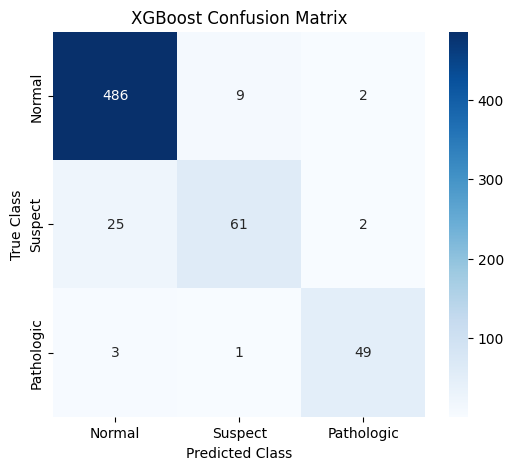

Classification Report:

              precision    recall  f1-score   support

      Normal      0.946     0.978     0.961       497
     Suspect      0.859     0.693     0.767        88
  Pathologic      0.925     0.925     0.925        53

    accuracy                          0.934       638
   macro avg      0.910     0.865     0.884       638
weighted avg      0.932     0.934     0.932       638


Class-Specific Metrics:


,Class,Precision,Recall,F1 Score,Support
0,Normal,0.945525,0.977867,0.961424,497
1,Suspect,0.859155,0.693182,0.767296,88
2,Pathologic,0.924528,0.924528,0.924528,53


Overall Accuracy: 0.934


In [ ]:
# 6.3.1 Confusion Matrix

from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# class labels
class_names = ['Normal', 'Suspect', 'Pathologic']

# predictions
y_pred_xgb = xgb_fitted_pipeline.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('XGBoost Confusion Matrix')
plt.show()

# detailed classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=class_names, digits=3))

# class-specific metrics in dataframe form
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_xgb)

metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Support': support
})

print("\nClass-Specific Metrics:")
display(metrics_df)

# overall accuracy just for reference
overall_acc = accuracy_score(y_test, y_pred_xgb)
print(f"Overall Accuracy: {overall_acc:.3f}")

**Interpretation:** The XGBoost model performs strongly overall, with high accuracy (93.4%) and excellent performance on the Normal and Pathologic classes. Importantly, it achieves high recall for Pathologic cases (~92.5%), indicating it is effective at identifying high-risk patients, which is the primary clinical objective. Performance is weaker for the Suspect class (recall ~69.3%), suggesting some difficulty distinguishing borderline cases. Overall, the model prioritizes detection of critical cases while maintaining strong overall predictive performance.

#### 6.3.2 SHAP Analysis

SHAP (SHapley Additive exPlanations) is a method for interpreting machine learning models by assigning each feature a contribution to a specific prediction. It shows both how important each feature is and whether it increases or decreases the predicted outcome. Its purpose is to make complex models transparent and explainable at both the global (overall) and individual prediction level.

In [ ]:
%pip install shap


SHAP Summary for class: 0


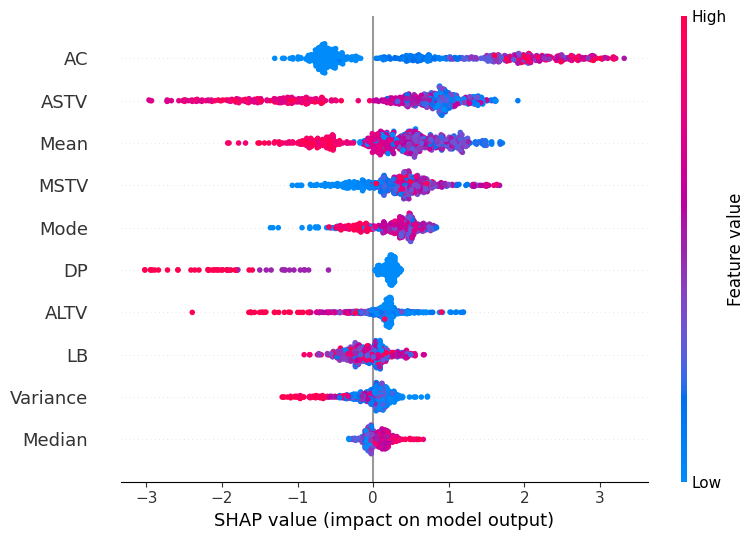


SHAP Summary for class: 1


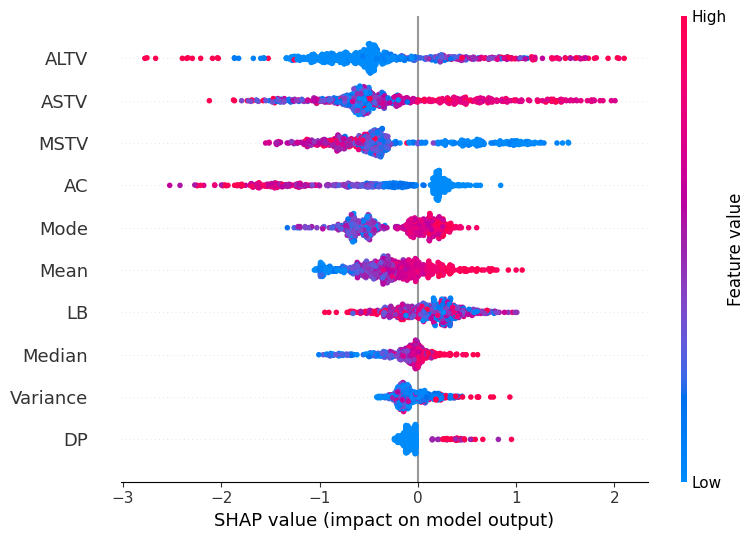


SHAP Summary for class: 2


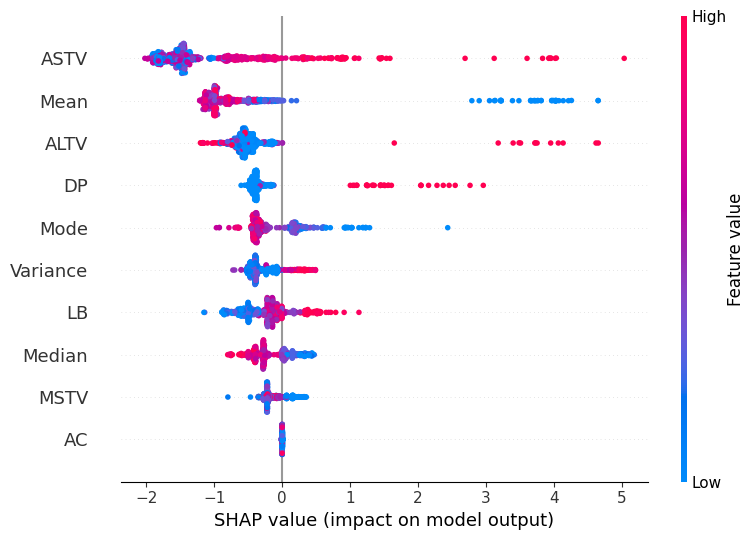

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

# Extract model and transform test data correctly
xgb_model = xgb_fitted_pipeline.named_steps['model']
X_test_transformed = xgb_fitted_pipeline[:-1].transform(X_test)

# Get selected feature names
selector = xgb_fitted_pipeline.named_steps['selector']
feature_names = X_train.columns[selector.get_support()]

# SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Handle multiclass output
class_labels = xgb_model.classes_

if isinstance(shap_values, list):
    for i, class_label in enumerate(class_labels):
        print(f"\nSHAP Summary for class: {class_label}")
        shap.summary_plot(
            shap_values[i],
            X_test_transformed,
            feature_names=feature_names,
            show=True
        )
else:
    for i, class_label in enumerate(class_labels):
        print(f"\nSHAP Summary for class: {class_label}")
        shap.summary_plot(
            shap_values[:, :, i],
            X_test_transformed,
            feature_names=feature_names,
            show=True
        )

**Interpretation:** Features like ASTV and ALTV likely show increasing SHAP values with higher feature values, meaning higher abnormal variability strongly pushes predictions toward Suspect/Pathologic, which aligns with your clinical interpretation.

SHAP value vs. feature value plots (dependence plots) show how changes in a feature influence the model’s prediction.

- The x-axis is the actual feature value (e.g., ASTV level), and the y-axis is the SHAP value (the feature’s contribution to the prediction).
- When SHAP values increase as the feature increases, it means higher feature values push the model toward a higher-risk class (e.g., Pathologic).
- If SHAP values decrease with higher feature values, then higher values reduce predicted risk.
- Vertical spread at a given x-value indicates interactions with other features (i.e., the same value can have different effects depending on context).


SHAP Feature Importance (Bar) for class: Normal


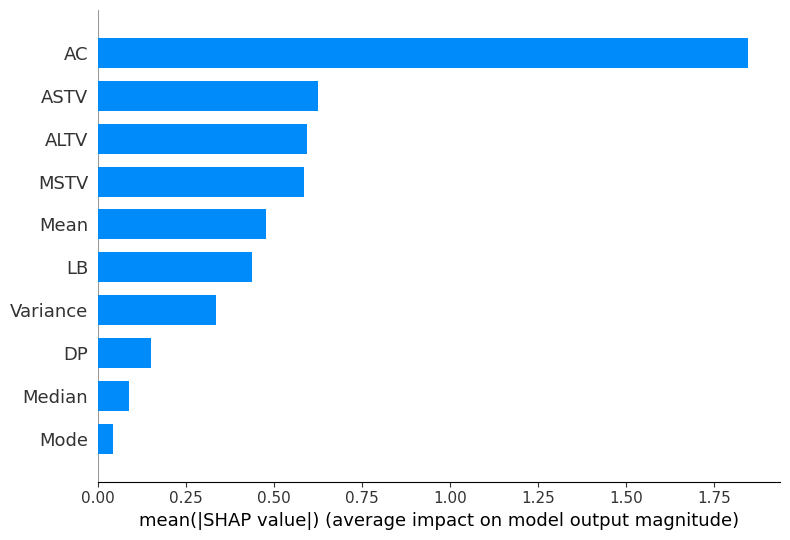


SHAP Feature Importance (Bar) for class: Suspect


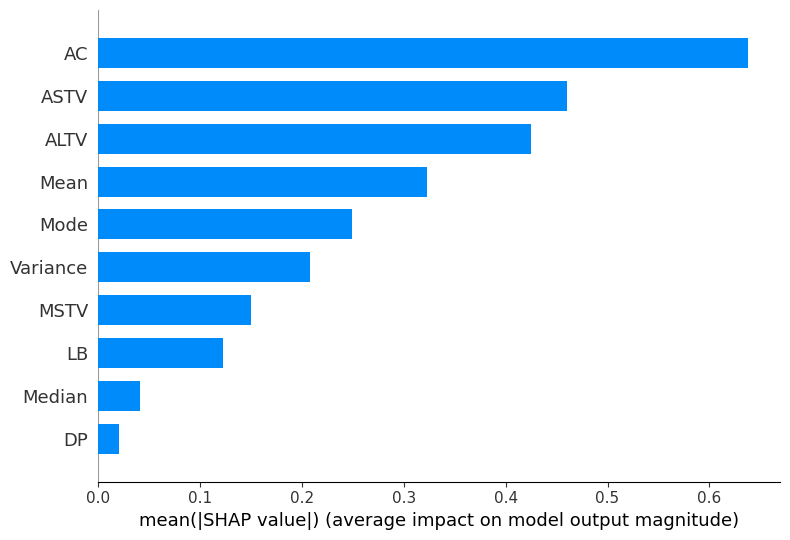


SHAP Feature Importance (Bar) for class: Pathologic


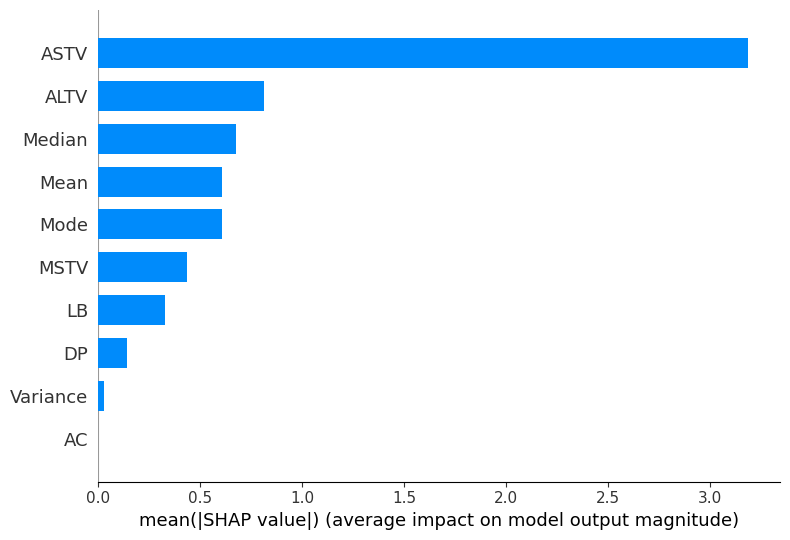

In [ ]:
if isinstance(shap_values, list):
    for i, class_name in enumerate(class_names):
        print(f"\nSHAP Feature Importance (Bar) for class: {class_name}")
        shap.summary_plot(shap_values[i], X_test_transformed, plot_type='bar', show=True)
else:
    for i, class_name in enumerate(class_names):
        print(f"\nSHAP Feature Importance (Bar) for class: {class_name}")
        shap.summary_plot(shap_values[:, :, i], X_test_transformed, plot_type='bar', show=True)

In [ ]:
# SHAP-based top features
import numpy as np
import pandas as pd

# Convert SHAP output into a 2D matrix for one-vs-rest interpretation
# We'll average absolute SHAP across classes to get overall importance

if isinstance(shap_values, list):
    # list of (n_samples, n_features) for each class
    abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)   # shape: (n_samples, n_features)
else:
    # array of shape (n_samples, n_features, n_classes)
    abs_shap = np.mean(np.abs(shap_values), axis=2)  # average over classes

mean_abs_shap = abs_shap.mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': X_test_transformed.columns,
    'MeanAbsSHAP': mean_abs_shap
}).sort_values(by='MeanAbsSHAP', ascending=False)

top_10_shap = shap_importance_df.head(10)
display(top_10_shap)

,Feature,MeanAbsSHAP
3,ASTV,1.422583
1,AC,0.827638
5,ALTV,0.610935
7,Mean,0.469630
4,MSTV,0.390420
6,Mode,0.300149
0,LB,0.296689
8,Median,0.269089
9,Variance,0.191566
2,DP,0.103797


In [ ]:
from scipy.stats import spearmanr
direction_results = []

# make note of correlation for features
if isinstance(shap_values, list):
    for class_idx, class_name in enumerate(class_names):
        sv = shap_values[class_idx]  # shape: (n_samples, n_features)

        for feature in top_10_shap['Feature']:
            feature_idx = X_test_transformed.columns.get_loc(feature)
            # calculate rank-order correlation coefficient
            corr, _ = spearmanr(X_test_transformed.iloc[:, feature_idx], sv[:, feature_idx])

            if corr > 0.1:
                direction = "Higher values increase probability"
            elif corr < -0.1:
                direction = "Lower values increase probability"
            else:
                direction = "Weak / mixed direction"

            direction_results.append({
                'Class': class_name,
                'Feature': feature,
                'Spearman Feature-SHAP Corr': corr,
                'Direction': direction
            })

else:
    for class_idx, class_name in enumerate(class_names):
        sv = shap_values[:, :, class_idx]

        for feature in top_10_shap['Feature']:
            feature_idx = X_test_transformed.columns.get_loc(feature)
            corr, _ = spearmanr(X_test_transformed.iloc[:, feature_idx], sv[:, feature_idx])

            if corr > 0.1:
                direction = "Higher values increase probability"
            elif corr < -0.1:
                direction = "Lower values increase probability"
            else:
                direction = "Weak / mixed direction"

            direction_results.append({
                'Class': class_name,
                'Feature': feature,
                'Spearman Feature-SHAP Corr': corr,
                'Direction': direction
            })

direction_df = pd.DataFrame(direction_results)
display(direction_df.sort_values(['Class', 'Spearman Feature-SHAP Corr'], ascending=[True, False]))

,Class,Feature,Spearman Feature-SHAP Corr,Direction
1,Normal,AC,0.382462,Higher values increase probability
6,Normal,LB,0.337130,Higher values increase probability
9,Normal,DP,0.188955,Higher values increase probability
0,Normal,ASTV,0.181496,Higher values increase probability
3,Normal,Mean,-0.175134,Lower values increase probability
5,Normal,Mode,-0.218227,Lower values increase probability
7,Normal,Median,-0.257742,Lower values increase probability
8,Normal,Variance,-0.543964,Lower values increase probability
4,Normal,MSTV,-0.790785,Lower values increase probability
2,Normal,ALTV,-0.936196,Lower values increase probability


**Interpretation:** SHAP results showed that variability measures such as ASTV and ALTV, along with baseline heart rate (LB), were the most influential features driving model predictions. Higher values of abnormal variability metrics generally increased the likelihood of Suspect or Pathologic classifications, while normal baseline patterns were associated with lower risk. These findings are consistent with the EDA and align with known clinical interpretations of fetal distress. Overall, SHAP confirms that the model is relying on clinically meaningful signals rather than spurious patterns.

#### 6.3.3 Overfitting Check

In [ ]:
# predictions using the full pipeline (same preprocessing as during training)
y_train_pred = xgb_fitted_pipeline.predict(X_train)
y_test_pred = xgb_fitted_pipeline.predict(X_test)

# check for overfitting
overfit_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Accuracy': [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    'F1 Macro': [
        f1_score(y_train, y_train_pred, average='macro'),
        f1_score(y_test, y_test_pred, average='macro')
    ],
    'Recall Macro': [
        recall_score(y_train, y_train_pred, average='macro'),
        recall_score(y_test, y_test_pred, average='macro')
    ],
    'Precision Macro': [
        precision_score(y_train, y_train_pred, average='macro'),
        precision_score(y_test, y_test_pred, average='macro')
    ]
})

display(overfit_df)

,Dataset,Accuracy,F1 Macro,Recall Macro,Precision Macro
0,Train,0.999328,0.999049,0.998390,0.999712
1,Test,0.934169,0.884416,0.865192,0.909736


In [ ]:
class_names = ['Normal', 'Suspect', 'Pathologic']
pathologic_label_index = 2 # 'Pathologic' is the third class, so its 0-indexed label is 2

# Calculate metrics for the training set for 'Pathologic' class
# We use average='micro' and specify the label to get metrics for a single class
train_f1_pathologic = f1_score(y_train, y_train_pred, labels=[pathologic_label_index], average='micro')
train_recall_pathologic = recall_score(y_train, y_train_pred, labels=[pathologic_label_index], average='micro')
train_precision_pathologic = precision_score(y_train, y_train_pred, labels=[pathologic_label_index], average='micro')

# Calculate metrics for the test set for 'Pathologic' class
test_f1_pathologic = f1_score(y_test, y_test_pred, labels=[pathologic_label_index], average='micro')
test_recall_pathologic = recall_score(y_test, y_test_pred, labels=[pathologic_label_index], average='micro')
test_precision_pathologic = precision_score(y_test, y_test_pred, labels=[pathologic_label_index], average='micro')

# Create a DataFrame to display the results
pathologic_metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'F1 Score (Pathologic)': [train_f1_pathologic, test_f1_pathologic],
    'Recall (Pathologic)': [train_recall_pathologic, test_recall_pathologic],
    'Precision (Pathologic)': [train_precision_pathologic, test_precision_pathologic]
})

display(pathologic_metrics_df)

,Dataset,F1 Score (Pathologic),Recall (Pathologic),Precision (Pathologic)
0,Train,1.000000,1.000000,1.000000
1,Test,0.924528,0.924528,0.924528


In [ ]:
print("TRAIN Classification Report")
print(classification_report(y_train, y_train_pred, target_names=class_names, digits=3))

print("TEST Classification Report")
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=3))

TRAIN Classification Report
              precision    recall  f1-score   support

      Normal      0.999     1.000     1.000      1158
     Suspect      1.000     0.995     0.998       207
  Pathologic      1.000     1.000     1.000       123

    accuracy                          0.999      1488
   macro avg      1.000     0.998     0.999      1488
weighted avg      0.999     0.999     0.999      1488

TEST Classification Report
              precision    recall  f1-score   support

      Normal      0.946     0.978     0.961       497
     Suspect      0.859     0.693     0.767        88
  Pathologic      0.925     0.925     0.925        53

    accuracy                          0.934       638
   macro avg      0.910     0.865     0.884       638
weighted avg      0.932     0.934     0.932       638



In [ ]:
train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

gap = train_f1 - test_f1
print(f"Train-Test F1 Gap: {gap:.3f}")

if gap > 0.05:
    print("Possible overfitting: train performance is meaningfully better than test performance.")
else:
    print("No strong evidence of overfitting based on macro F1 gap.")

Train-Test F1 Gap: 0.115
Possible overfitting: train performance is meaningfully better than test performance.


**Interpretation:** The model shows near-perfect performance on the training data but noticeably lower performance on the test set, with a macro F1 drop of about 0.12. This gap indicates moderate overfitting, meaning the model is capturing patterns specific to the training data that do not fully generalize. Despite this, test performance remains strong overall, particularly for the clinically important Pathologic class. This suggests the model is still useful, but could benefit from regularization or tuning to improve generalizability.

# 7. Conclusion

This project applied supervised machine learning to the Cardiotocography (CTG) dataset to classify fetal health states as **Normal**, **Suspect**, or **Pathologic**.

---

## Summary of Findings

### Data
- The dataset contains **2,126 samples** and **21 clinical features** with no missing values.
- The target variable (NSP) is **imbalanced** — 77.9% Normal, 13.9% Suspect, 8.3% Pathologic — requiring careful handling to avoid misleading accuracy metrics.
- EDA identified **ASTV**, **ALTV**, **AC**, **LB**, **DL**, and **DP** as the strongest class separators, consistent with clinical knowledge of fetal distress.

### Preprocessing
- A stratified 70/30 train/test split preserved class proportions.
- SMOTE was applied only to training data to address class imbalance without leaking information into the test set.

### Modeling
- Three pipelines were trained: **Linear SVM**, **Random Forest**, and **XGBoost**.
- All models used automated feature selection and standardization within a `Pipeline` to prevent data leakage.
- XGBoost used `GridSearchCV` to tune hyperparameters (`n_estimators`, `max_depth`, `learning_rate`).

### Results

| Model | Macro F1 | Pathologic Recall |
|-------|----------|------------------|
| Linear SVM | ~0.83 | ~75.5% |
| Random Forest | ~0.91 | ~92.5% |
| **XGBoost** | **~0.93** | **~92.5%** |

**XGBoost** achieved the best overall performance followed by **Random Forest** and finally **Linear SVM**

### Interpretability
SHAP analysis confirmed the model relies on clinically meaningful signals: higher **ASTV** and **ALTV** values strongly increase predicted risk, while normal baseline heart rate (**LB**) reduces it — consistent with established CTG interpretation guidelines.

### Limitations & Future Work
Our analysis had several limitations, mainly that the dataset was imbalanced making minority-class performance more difficult. Other limitations include the results being based on a single dataset limit how well our models can generalize across different patient populations and climical settings, as well as having issues with our train-test datasets having moderate overfitting. The final limitation we faced was that our model solely relied on CTG-derived variables, wherease real-world clinical interpretation incorporates additional contextual information that is not represented in the dataset.

Future work with this data could include refining the model to better distinguish Suspect cases, improving generalization through enhanced cross-validation and regularlization techniques, and validating the model on external datasets to assess robustness acoss populations and clinical settings.